# Testing AirGravQC - AGG Data

Mark Dransfield 22 March 2023

> This notebook uses the Canobie survey data to test the AirGravQC Python module. This also serves as a demonstration of the use of `AirGravQC` on AGG data.

> Throughout this notebook, text indented like this paragraph, and the paragraphs before and after, indicates commentary intended to explain the purpose, or highlight some feature of, the code and text of the nearby cells. The commentary is an addition to the notebook and is intended to provide extra information to someone planning to use `AirGravQC`.

> Some of the comments are provided as examples and do not necessarily reflect problems that actually occurred in the supplied data. The Canobie data were in fact very good.

> The commentary does not document the software but the usual `CMD-I` click on any function will provide the doc-string help.

> The introduction usually contains a summary of the data and results of QC. It should be written according to the needs of the project but might look something like ...

## Introduction

This notebook summarises the QC of the field data delivered by Xcalibur Aviation (Australia) Pty Ltd on 30 Nov 2021 for the Geoscience Australia (GA) Airborne Gravity Gradiometry (AGG) Survey flown in Queensland (Canobie Block).

The Canobie Block is Xcalibur project number 902212 and GA project number ###.

The notebook is organised in line with the Technical Specifications for the survey.

A total of 3,360.5 km of data (out of a planned 4,985.7 km) were delivered from 7 flights and 56 lines.

**All data passed review and were accepted with no re-flights.**

The first section of this notebook imports the data into the QC system and summarises the contents. The QC checks of the data are organised into following sections: Reports and Data Formats, Navigation and Positioning, Gravity, and Grids.

> The idea is that every QC check required by the contract and performed by the QC person will be in this notebook. Many checks are performed by running code from `AirGravQC` and the call to the code, and the output, are contained herein. Some checks (for example, was a Daily Report delivered each day) are not amenable to a check by software but they should still be noted, with the outcome of the check, within the notebook. There are also a few additional checks I like to perform. Some fall naturally under the umbrella of "best practice" and some are based on my experience. The reader should not feel obliged to use these checks themselves but they might find them useful.

> I also colour code the results to make it easy to find the areas that require more work.

#### QC Colour Coding

Summary cells are coloured to quickly indicated status against QC. The colours are:

<div class="alert alert-block alert-success">
Delivery passed QC.
<div>

<div class="alert alert-block alert-info">
Delivery was not checked, or the check is not applicable, or there is a minor shortcoming but is the data are acceptable.
<div>

<div class="alert alert-block alert-warning">
Delivery failed QC and problem has been reported for rectification.
<div>

<div class="alert alert-block alert-danger">
Delivery failed QC and problem might not be readily rectified. This is very rare.
<div>

## Import and Summarise

#### Import required modules, and set filenames for data and plan.

In [1]:
import sys
import importlib as im

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib widget

from pathlib import Path

> Set the paths for the software and import. (One day this will require fewer steps.)

In [2]:
local_docs = "/Users/markdransfield/"
src_path = local_docs + "Documents/GitHub/AirGravQC/src"
sys.path.insert(0, src_path)

import pointfiles as mhd
import qualityAnalysis as qc
import whizzPlot as wp
import gridfiles as erm

> Set the paths for the data. This Canobie delivery did not have a drape plan, nor any gridded data.

> Modify to suit your data.

In [3]:
data_root = "/Users/markdransfield/Documents/GitHub/AirGravQC/examples/"
dx = Path(data_root + r'AGG/Canobie/20211130.xyz')
dh = dx.with_suffix('.hdf5')

# Sometimes, but not this time, the plan data is in a different directory ...
plan_root = data_root
px = Path(plan_root + r'AGG/Canobie/902212_1.xyz')
ph = px.with_suffix('.hdf5')

### Measured Data

#### Convert measured XYZ data to geoWhizz, and set metadata

> The next step is essential. We need the data in HDF5 geoWhizz format because all the QC functions expect that format.

> Geosoft XYZ files generally have only the channel names, and no other metadata. We need the attributes of the data at project level, at line number level, and at data channel level.

> Project level metadata attributes can be added here. The example could include others as well as `projectName` ...

In [5]:
mhd.xyzToHDF(Path(dx), projectName='Canobie')

Accessing XYZ data in /Users/markdransfield/Documents/GitHub/AirGravQC/examples/AGG/Canobie/20211130.xyz.
First few records are:
   /ANE_TC_2p67 AUV_TC_2p67    Bearing BNE_TC_2p67 BUV_TC_2p67  CLEARANCE       Date        DTM    EASTING     FIDUCIAL FLIGHT gD_Fourier_2p67 GDD_Fourier_2p67 GNE_Fourier_2p67 GUV_Fourier_2p67       HDOP     HEIGHT     JOB_ID         LATITUDE       LINE        LONGITUDE   Noise_NE   Noise_UV   NORTHING NumSats       PDOP       T_DD       T_NE       T_UV  Time_1980   Time_Day TURBULENCE       VDOP

   Line  100010


  Found 1 header records
  Found 56 lines
  Found 33 fields

Creating:  /Users/markdransfield/Documents/GitHub/AirGravQC/examples/AGG/Canobie/20211130.hdf5


PosixPath('/Users/markdransfield/Documents/GitHub/AirGravQC/examples/AGG/Canobie/20211130.hdf5')

> ... but this way, we demonstrate the use of `updateProject()` to add additional project attributes.

> It also shows the use of `updateCoordFrame()` which keeps track of the coordinate definition and the names of the channels that contain position and time. Many QC routines use position and time, so it saves effort later to have this information in the geoWhizz group attributes.

> Field data are commonly delivered to WGS84, projected to UTM, because that is what GNSS delivers. Transformation to the desired datum happens at the end of the project for the final data.

In [6]:
block_name = 'Prelim Canobie Data'
mhd.updateProject(dh, acquirer='Xcalibur', blockID=block_name)
mhd.updateCoordFrame(dh, lat='LATITUDE', lon='LONGITUDE', x='EASTING', y='NORTHING', time='Time_1980', alt='HEIGHT')
mhd.updateCoordFrame(dh, geoDatum='WGS84', htDatum='WGS84', projection='UTM', utmz='54')

Setting BlockID = Prelim Canobie Data for 20211130.hdf5.
Setting Acquirer = Xcalibur for 20211130.hdf5.
Changed CoordFrame attribute(s) for 20211130.hdf5.
Changed CoordFrame attribute(s) for 20211130.hdf5.


> The line attributes represent a challenge. Line numbers are usually coded to contain a number of impoprtant attributes: whether the line is a traverse, control, repeat or test line; which segment of a number of segments needed to complete the line, and whether it is a re-flight; and what is the line number of the corresponding planned line number. Each supplier uses a different coding system, and sometimes they will use different codings for different projects (or, worst of all (but vary rare), between staff processing the data on the same project!).

> AirGravQC knows only 3 of these systems so far and this will need expanding. So beware!

In [7]:
mhd.updateLineAttributes(dh, line_type='Xcal_can')


Setting Line attributes for 20211130.hdf5 according to the Xcal_can scheme.
  Line No.       Plan Line No.  Segment No.    Re-flight No.  
  100010.0       100010.0       0              0              
  100020.0       100020.0       0              0              
  100030.0       100030.0       0              0              
  100040.0       100040.0       0              0              
  100050.0       100050.0       0              0              
  100060.0       100060.0       0              0              
  100070.0       100070.0       0              0              
  100080.0       100080.0       0              0              
  100090.0       100090.0       0              0              
  100100.0       100100.0       0              0              
  100110.0       100110.0       0              0              
  100120.0       100120.0       0              0              
  100130.0       100130.0       0              0              
  100140.0       100140.0       0        

> The acquirers of the data supplied a separate text file `Channel Descriptions.txt` with the requisite channel attributes metadata which then had to be entered manually via this series of commands to store it in the geoWhizz file created by `xyzToHDF()`. There is some drudgery involved here which you will have to do for your project.

> I did not enter in the supplied descriptions for the channel attributes so all that is happening here is storing the units for each channel. Units are used in some QC checking. *Could we automate this process by reading channel description files?*

In [8]:
mhd.updateChannelAttributes(dh, 'ANE_TC_2p67', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'AUV_TC_2p67', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'Bearing', units='degrees', description='')
mhd.updateChannelAttributes(dh, 'BNE_TC_2p67', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'BUV_TC_2p67', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'CLEARANCE', units='metre', description='')
mhd.updateChannelAttributes(dh, 'Date', description='')
mhd.updateChannelAttributes(dh, 'DTM', units='metre', description='')
mhd.updateChannelAttributes(dh, 'EASTING', units='metre', description='')
mhd.updateChannelAttributes(dh, 'FIDUCIAL', description='')
mhd.updateChannelAttributes(dh, 'FLIGHT', description='')
mhd.updateChannelAttributes(dh, 'gD_Fourier_2p67', units='µm/s/s', description='')
mhd.updateChannelAttributes(dh, 'GDD_Fourier_2p67', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'GNE_Fourier_2p67', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'GUV_Fourier_2p67', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'HDOP', description='')
mhd.updateChannelAttributes(dh, 'HEIGHT', units='metre', description='')
mhd.updateChannelAttributes(dh, 'JOB_ID', description='')
mhd.updateChannelAttributes(dh, 'LATITUDE', units='degree', description='')
mhd.updateChannelAttributes(dh, 'LINE', description='')
mhd.updateChannelAttributes(dh, 'LONGITUDE', units='degree', description='')
mhd.updateChannelAttributes(dh, 'Noise_NE', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'Noise_UV', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'NORTHING', units='metre', description='')
mhd.updateChannelAttributes(dh, 'NumSats', description='')
mhd.updateChannelAttributes(dh, 'PDOP', description='')
mhd.updateChannelAttributes(dh, 'T_DD', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'T_NE', units='eotvos', description='')
mhd.updateChannelAttributes(dh, 'T_UV', units='µm/s/s', description='')
mhd.updateChannelAttributes(dh, 'Time_1980', units='seconds', description='')
mhd.updateChannelAttributes(dh, 'Time_Day', units='seconds', description='')
mhd.updateChannelAttributes(dh, 'TURBULENCE', units='m/s/s', description='')
mhd.updateChannelAttributes(dh, 'VDOP', description='')

Changed channel attribute(s) for ANE_TC_2p67 in 20211130.hdf5.
Changed channel attribute(s) for AUV_TC_2p67 in 20211130.hdf5.
Changed channel attribute(s) for Bearing in 20211130.hdf5.
Changed channel attribute(s) for BNE_TC_2p67 in 20211130.hdf5.
Changed channel attribute(s) for BUV_TC_2p67 in 20211130.hdf5.
Changed channel attribute(s) for CLEARANCE in 20211130.hdf5.
Changed channel attribute(s) for DTM in 20211130.hdf5.
Changed channel attribute(s) for EASTING in 20211130.hdf5.
Changed channel attribute(s) for gD_Fourier_2p67 in 20211130.hdf5.
Changed channel attribute(s) for GDD_Fourier_2p67 in 20211130.hdf5.
Changed channel attribute(s) for GNE_Fourier_2p67 in 20211130.hdf5.
Changed channel attribute(s) for GUV_Fourier_2p67 in 20211130.hdf5.
Changed channel attribute(s) for HEIGHT in 20211130.hdf5.
Changed channel attribute(s) for LATITUDE in 20211130.hdf5.
Changed channel attribute(s) for LONGITUDE in 20211130.hdf5.
Changed channel attribute(s) for Noise_NE in 20211130.hdf5.
Chan

#### Summary report of measured data

> Summary report of contents of data file. The `reportWhizz()` code can list attributes of a line via the `line=...` keyword, or a channel via the `channel=...` keyword.

In [9]:
mhd.reportWhizz(dh)

Whizz Version 1.0
    Acquirer: Xcalibur
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

Coordinates
    AltitudeChannel: HEIGHT
    GeoDatum: WGS84
    HeightDatum: WGS84
    LatitudeChannel: LATITUDE
    LongitudeChannel: LONGITUDE
    Projection: UTM
    TimeChannel: Time_1980
    UTMZone: 54
    XChannel: EASTING
    YChannel: NORTHING
56 lines: total distance flown [km] = 3,360.5

56 lines:
 ['100010.0', '100020.0', '100030.0', '100040.0', '100050.0', '100060.0', '100070.0', '100080.0', '100090.0', '100100.0', '100110.0', '100120.0', '100130.0', '100140.0', '100160.0', '100170.0', '100180.0', '100190.0', '100200.0', '100210.0', '100220.0', '100230.0', '100240.0', '100250.0', '100260.0', '100271.0', '100280.0', '100290.0', '100300.0', '100310.0', '100320.0', '100330.0', '100340.0', '100360.0', '100390.0', '100400.0', '100410.0', '100420.0', '100430.0', '100440.0', '100450.0', '100460.0', '100470.0', '100480.0', '100490.0', '100500.0', '100510.0', '100520.0', '100530.0', 

In [10]:
mhd.reportFlights(dh, detailed=True)

Whizz Version 1.0
    Acquirer: Xcalibur
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

7 flights over 56 lines.

Flights
    2
        L100010.0 L100020.0 
    3
        L100030.0 L100040.0 L100050.0 L100060.0 
    4
        L100070.0 L100080.0 L100090.0 L100100.0 L100110.0 L100120.0 L100130.0 L100140.0 L100160.0 
    5
        L100170.0 L100180.0 L100190.0 L100200.0 L100210.0 L100220.0 L100230.0 L100240.0 L100250.0 L100260.0 
    6
        L100271.0 L100280.0 L100290.0 L100300.0 L100310.0 L100320.0 L100330.0 L100340.0 L100360.0 
    7
        L100390.0 L100400.0 L100410.0 L100420.0 L100430.0 L100440.0 L100450.0 L100460.0 L100470.0 L100480.0 
    8
        L100490.0 L100500.0 L100510.0 L100520.0 L100530.0 L100540.0 L100550.0 L100560.0 L100570.0 L100580.0 L100590.0 L100600.0 


> Sample times should be constant. Here we have one at 0.126 which ought to be checked. Sample distances vary with aircraft ground speed.

In [11]:
mhd.reportSampling(dh)

Whizz Version 1.0
    Acquirer: Xcalibur
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

Sample time and distance statistics
  Min  = 0.125 s, 6.5 m
  Max  = 0.126 s, 8.4 m
  Mean = 0.125 s, 7.5 m


### Plan Data

#### Convert plan XYZ data to geoWhizz, and set metadata

In this example, the plan data file only has the (x,y) locations of the start and end of each line and we have no planned heights. The process is the same as for the acquired survey data `XYZ` file above.

In [12]:
mhd.xyzToHDF(Path(px), projectName='Canobie')
block_name = 'Survey Plan'
mhd.updateProject(ph, acquirer='Xcalibur', blockID=block_name)

Accessing XYZ data in /Users/markdransfield/Documents/GitHub/AirGravQC/examples/AGG/Canobie/902212_1.xyz.
First few records are:
   /EASTING  NORTHING  FLAG

   LINE      1


  Found 1 header records
  Found 78 lines
  Found 3 fields

Creating:  /Users/markdransfield/Documents/GitHub/AirGravQC/examples/AGG/Canobie/902212_1.hdf5
Setting BlockID = Survey Plan for 902212_1.hdf5.
Setting Acquirer = Xcalibur for 902212_1.hdf5.


In [13]:
mhd.updateCoordFrame(ph, x='EASTING', y='NORTHING')
mhd.updateCoordFrame(ph, geoDatum='WGS84', projection='UTM', utmz='54')
mhd.updateLineAttributes(ph, line_type='Xcal_can')

Changed CoordFrame attribute(s) for 902212_1.hdf5.
Changed CoordFrame attribute(s) for 902212_1.hdf5.

Setting Line attributes for 902212_1.hdf5 according to the Xcal_can scheme.
  Line No.       Plan Line No.  Segment No.    Re-flight No.  
  1.0            0.0            0              1              
  100010.0       100010.0       0              0              
  100020.0       100020.0       0              0              
  100030.0       100030.0       0              0              
  100040.0       100040.0       0              0              
  100050.0       100050.0       0              0              
  100060.0       100060.0       0              0              
  100070.0       100070.0       0              0              
  100080.0       100080.0       0              0              
  100090.0       100090.0       0              0              
  100100.0       100100.0       0              0              
  100110.0       100110.0       0              0              
  

In [14]:
mhd.updateChannelAttributes(ph, 'EASTING', units='m')
mhd.updateChannelAttributes(ph, 'NORTHING', units='m')

Changed channel attribute(s) for EASTING in 902212_1.hdf5.
Changed channel attribute(s) for NORTHING in 902212_1.hdf5.


#### Summary report of plan data

In [15]:
mhd.reportWhizz(ph)

Whizz Version 1.0
    Acquirer: Xcalibur
    BlockID: Survey Plan
    ProjectName: Canobie

Coordinates
    GeoDatum: WGS84
    Projection: UTM
    UTMZone: 54
    XChannel: EASTING
    YChannel: NORTHING
78 lines: total distance flown [km] = 4,985.7

78 lines:
 ['1.0', '100010.0', '100020.0', '100030.0', '100040.0', '100050.0', '100060.0', '100070.0', '100080.0', '100090.0', '100100.0', '100110.0', '100120.0', '100130.0', '100140.0', '100150.0', '100160.0', '100170.0', '100180.0', '100190.0', '100200.0', '100210.0', '100220.0', '100230.0', '100240.0', '100250.0', '100260.0', '100270.0', '100280.0', '100290.0', '100300.0', '100310.0', '100320.0', '100330.0', '100340.0', '100350.0', '100360.0', '100370.0', '100380.0', '100390.0', '100400.0', '100410.0', '100420.0', '100430.0', '100440.0', '100450.0', '100460.0', '100470.0', '100480.0', '100490.0', '100500.0', '100510.0', '100520.0', '100530.0', '100540.0', '100550.0', '100560.0', '100570.0', '100580.0', '100590.0', '100600.0', '100610.0

#### Map showing flown lines against plan.

> This provides a visual check that the lines are in about the right location and shows the amount of the survey flown so far.

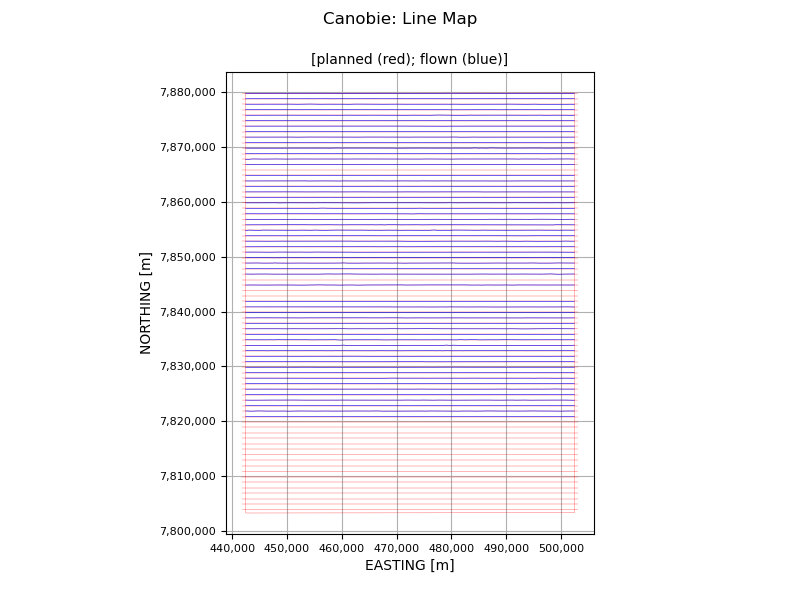

In [10]:
im.reload(wp)
wp.linesMap([dh], whizzPlanFile=ph)

## Reports and formats
<div class="alert alert-block alert-info">
ACCEPT
<div>

> All of the checks in this section are performed independently of the AirGravQC software and this notebook. But it is convenient to keep all the QC reporting in this one document.

> The acquirer is generally expected to deliver certain reports and data throughout the survey. The data are exxpected in certain formats. This section provides for reporting whether or not these requirements were met.

> Currently this example does not contain any reports. If it did, we would do the following checks.

#### Point located data format
<div class="alert alert-block alert-info">
ACCEPT
<div>

*Delivered point located field data shall be in ASEG-GDF2 format.*

Actually delivered in Geosoft XYZ. For field data this is not a problem so, even though this does not meet contractual requirements, it is acceptable. Channel descriptions file matches actual supplied channels as required.

#### Gridded data format
<div class="alert alert-block alert-info">
NA   
<div>

*The Deed specifies the gridded field data to be supplied. For the Canobie contract, none were required.*

> The Deed specifies ERMapper format.

No grids required and none supplied. Not applicable.

#### Static data to be supplied
<div class="alert alert-block alert-success">
PASS
<div>

*Gravity and navigation processed static readings must be reported to the Customer within 24 hours of every completed flight.*

Quiescent data has been supplied as required. This has been QC'd on a daily basis and no problems, concerns or failings were observed. All data has passed.

#### Field data to be supplied
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed specifies the required channels for field delivery.*

Line data - all required channels delivered.

Channel description text file supplied.

#### Delivered reports
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires a Commencement Report before acquisition commences, daily and weekly report through the project, and a final report at the end.*

Commencement report was received in timely manner and was checked against contract. All requirements met.

Daily reports have been received and have provided the information required under the contract.

Weekly reports - none received, supplier has been asked to rectify (email 30 Feb 2019).

Final report - only due at end of project.

#### Coordinates and Units
<div class="alert alert-block alert-info">
ACCEPT
<div>

*As per contract: Correct Coordinate Frame; correct Position Datum, Projected Coordinates and Height Datum; correct units.*

Checked manually.

Coord Frame - PASS

Position Datum - WGS84 incorrect but acceptable for field data.

Projected Coordinate - UTM 54 incorrect (should be MGA 54) but acceptable for field data.

Height Datum - EGM96 geoid incorrect but acceptable for field data.

Units - all correct except gravity which is in mGal instead of µm/s/s. Accept since field data.

> I accept WGS84/UTM and I accept mGal for field data even though the Deed specifies GDA2020 / MGA and um/s/s. Enforcing the contract makes extra work for the acquirer on every delivery for usually no advantage.

## Navigation and positioning
<div class="alert alert-block alert-info">
ACCEPT
<div>

#### GNSS
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires a minimum of 5 GNSS satellites visible for AGG acquisition, and PDOP, HDOP and VDOP to not exceed 4.*

All ok.

In [7]:
im.reload(qc)
qc.qc_nav.checkGNSS(dh, 'NumSats', 'PDOP', 'VDOP', 'HDOP', nsats_min=5, max_pdop=4, 
                  max_hdop=4, max_vdop=4)

NameError: name 'h5py' is not defined

> The above exemplifies my preferred reporting structure, with the contractual specification first, then any commentary or summary of QC, and finally, the actual QC check performed with its output. (`checkGNSS()` is the first instance in this notebook with all elements of the structure present.)

#### Horizontal Position
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires the horizontal position to not depart from the planned position by more than 40 m for more than 1000 m.*

All ok.

In [18]:
qc.checkXYPlan(ph, dh, allowance=40.0, maxCounter=0, maxDistance=1000.0, plot_flag=False)


0 exceedances known in the database.

0 lines not in plan and not checked.

0 horizontal exceedances.

0 lines with horizontal exceedances.



#### Vertical Position
<div class="alert alert-block alert-info">
NA
<div>

*The Deed requires the vertical position to not depart from the planned position by more than 20 m for more than 1000 m.*

> I can't find the planned drape for Canobie, but it proceeds very like the horizontal one.

In [25]:
qc.checkVertPlan(ph, dh, allowance=20.0, maxCounter=0, maxDistance=1000.0, plot_flag=False)

KeyError: "Can't open attribute (can't locate attribute: 'AltitudeChannel')"

#### Cross-over Heights
<div class="alert alert-block alert-info">
NA
<div>

*The Deed requires that the difference in height between traverse and control lines is less than some agreed maximum value.*

There are no control lines at Canobie and no specification so NA.

#### Segment Lengths
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires a minimum line segment length. For Canobie, it was 11.2 km.*

OK

In [19]:
qc.checkLineLengths(dh, min_len=11.2)

Number failed lines = 0


#### Line Overlaps
<div class="alert alert-block alert-success">
PASS
<div>

*The minimum overlap between segments of a line should be 600 m for AGG.*

> The report could be more informative here - "all overlaps met the requirement", say

In [20]:
qc.checkOverlaps(dh, min_overlap=0.6, plot_flag=False)

0 coincident lines found.



#### Ground Clearance
<div class="alert alert-block alert-success">
PASS
<div>

*This is a non-contractual check that the aircraft did not approach the ground too closely; it is a simple safety check. The settings check if the aircraft came closer than 60 m from the ground. You can change this to a number of your choice.*

All ok. Also checked at 18 m just to get a plot!

In [29]:
qc.checkClearance(dh, 80.0, altitude_chan='HEIGHT', terrain_chan='DTM', allowance=20.0, only_low=True)

Number of failed lines = 0.



Number of failed lines = 1.

Clearance deviation of 18 m on line 100450.0


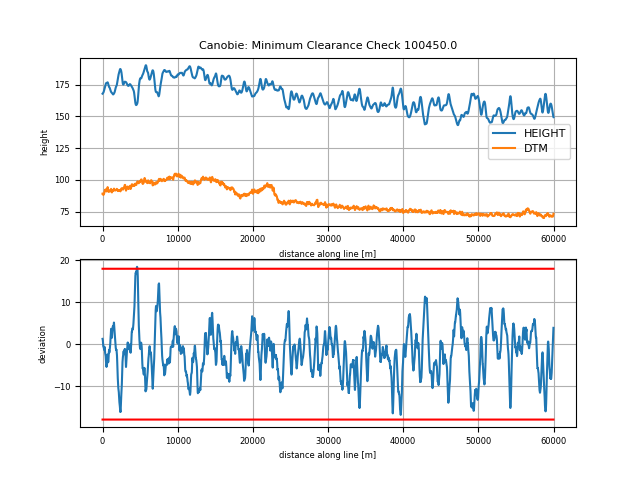

In [30]:
qc.checkClearance(dh, 80.0, altitude_chan='HEIGHT', terrain_chan='DTM', allowance=18.0, only_low=True)

#### Ground Speed
<div class="alert alert-block alert-success">
PASS
<div>

*The contract requires the ground speed to not exceed the range +/-15% of 60 m/s for more than 1000 m.*

OK.

In [31]:
qc.checkSpeeds(dh, nominalSpeed=60., allowance=0.15, maxDistance=1000.0, plot_flag=False)

Velocities not known - will calculate from positions
Nominal ground speed 60.0 m/s; allowed 51.0 : 69.0 for < 1000.0 m.

 Checked 56 lines and 0 had some short exceedance(s).
 0 lines failed for exceedance > allowed.
 Total number of full exceedances = 0.



## Gravity
<div class="alert alert-block alert-success">
PASS
<div>

#### Quiescent Noise
<div class="alert alert-block alert-success">
PASS
<div>

*Deed requires quiescent data collected before each flight and the results delivered in the the daily report. Average signal power density over both complements is required to be below $10E^{2}/rad/sec$.*

Quiescent data were supplied daily by email as required and were checked on arrival. All quiescent data was below 10 E^2/r/s as required.

#### AGG Noise
<div class="alert alert-block alert-success">
PASS
<div>

*Deed requires that any line with an average noise above 5.0 E be re-flown.*

OK

> The noise depends on turbulence so it is instructive to plot each noise channel against turbulence. This also shows any outliers from the general trend (the plot shows one such at turbulence just less than 0.8 and noise above 3.5 E, although this is not sufficiently different from the trend to be a concern.)

> Also note that the requirement is for the average of the errors in NE and UV to be less than 5.0 E, not for both.

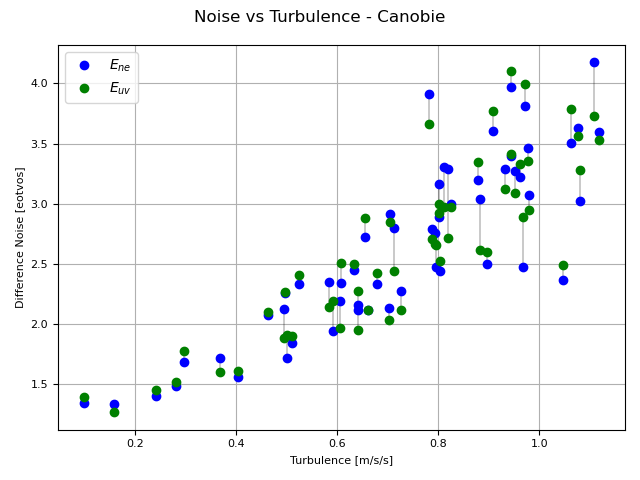

In [4]:
qc.diffNoiseVturb(whizzFile=dh, eNE='Noise_NE', eUV='Noise_UV', turbulence='TURBULENCE')

## Statistics and Grids

#### Data Quality
<div class="alert alert-block alert-success">
PASS
<div>

*None of the following checks are contractually required but they can give some insights to data quality.*

---
The only spikes found were at very small amplitudes on otherwise smooth fields (terrain corrections). All ok.

> The following channels should vary smoothly without spikes. You can choose different channels to test for your project but I have found this test to generally be too sensitive. The algorithm could be improved.

In [33]:
qc.checkSpikes(dh, fields=['Bearing', 'Noise_NE', 'Noise_UV', 'gD_Fourier_2p67', 'T_DD', 'T_NE', 'T_UV', \
                            'LATITUDE', 'LONGITUDE', 'EASTING', 'NORTHING', 'DTM'])


  100080.0; T_DD Extremum: 1.19 > 1.01 = 8.00 x STD of 0.13
  100080.0; T_UV Extremum: 0.35 > 0.31 = 8.00 x STD of 0.04
  100580.0; T_DD Extremum: 0.77 > 0.73 = 8.00 x STD of 0.09
  100590.0; T_DD Extremum: 0.78 > 0.74 = 8.00 x STD of 0.09
  100590.0; T_UV Extremum: 0.33 > 0.25 = 8.00 x STD of 0.03


---
The only failures are in the `Time_Day` channel and all are within 1 second of midnight. Time of day does not vary with constant slope at midnight so this is not a concern. Of course the aircraft was not flying at midnight, suggesting the the relevant clock is in the wrong time zone but this is not a concern.

> The checked fields should each vary uniformly with constant slope.

In [34]:
qc.checkConstantSlope(dh, fields=['Date', 'FIDUCIAL', 'FLIGHT', 'LINE', 'Time_Day', 'JOB_ID', \
                                   'Time_1980'])


  100130.0; Time_Day Largest difference (= 86389.57) > 1% of mean difference (= -0.10)
  100250.0; Time_Day Largest difference (= 86389.23) > 1% of mean difference (= -0.11)
  100470.0; Time_Day Largest difference (= 86389.21) > 1% of mean difference (= -0.11)
  100560.0; Time_Day Largest difference (= 86389.10) > 1% of mean difference (= -0.11)


---
All channel statistics look as expected. OK.

> Just plot the mean, standard deviation and range of every channel as a for every line. A lot of information condensed here which I find useful. I just run my eye quickly over the plots looking for outliers, and I check the vertical scales to ensure that the values are in about the right range.

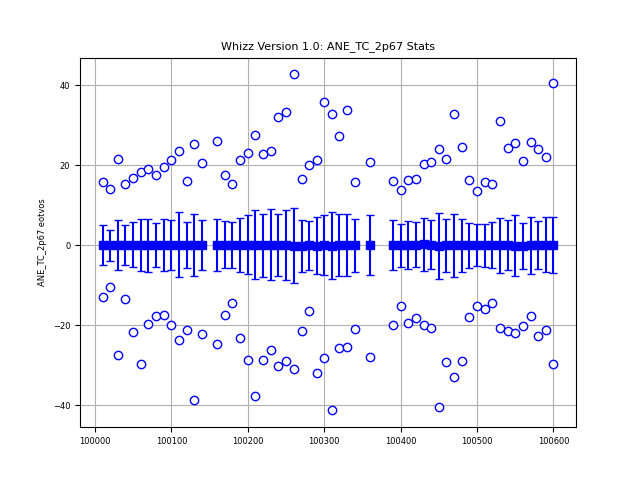

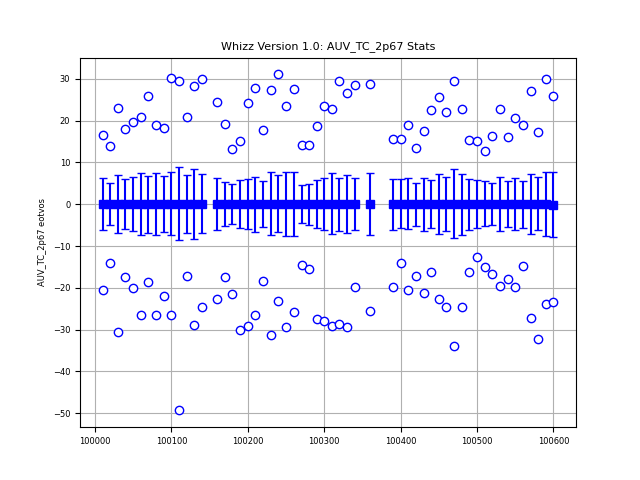

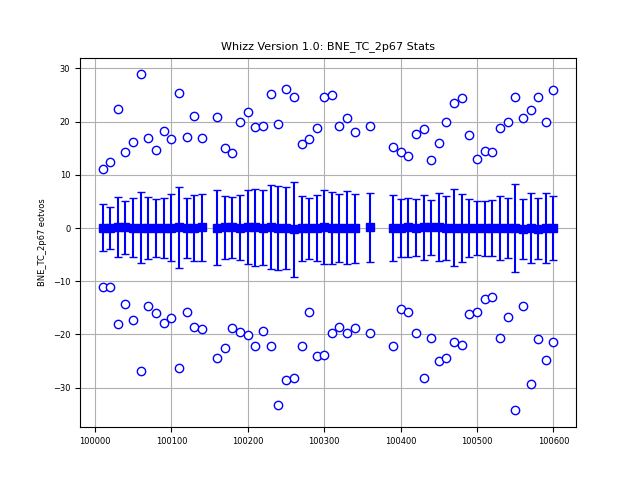

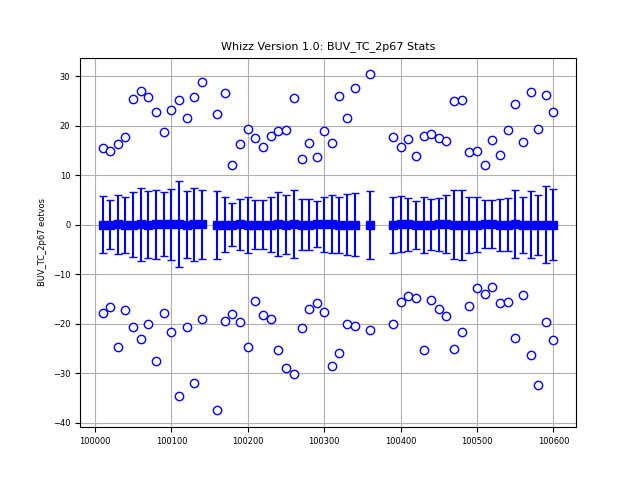

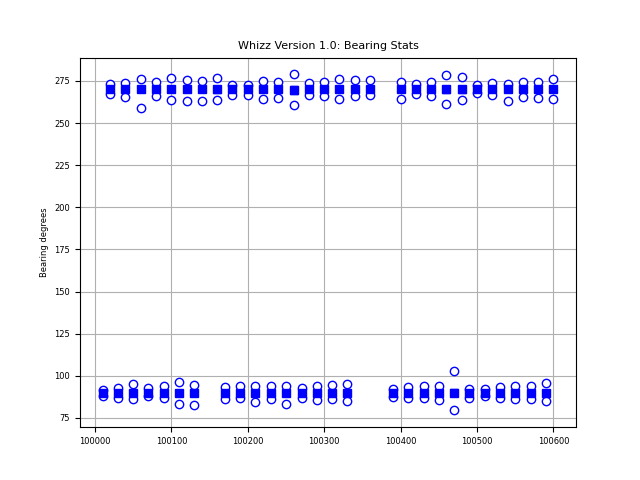

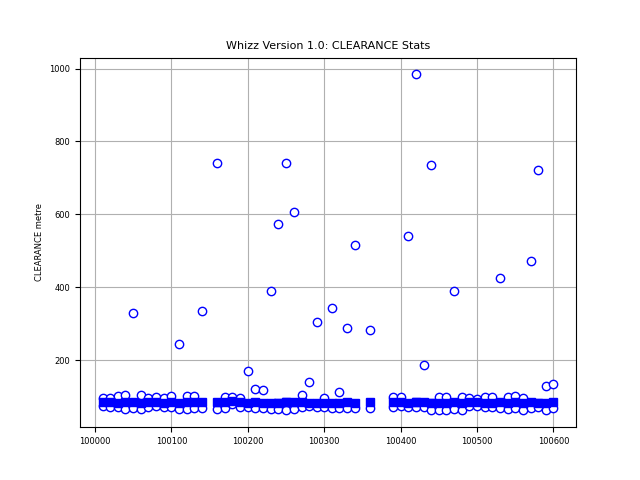

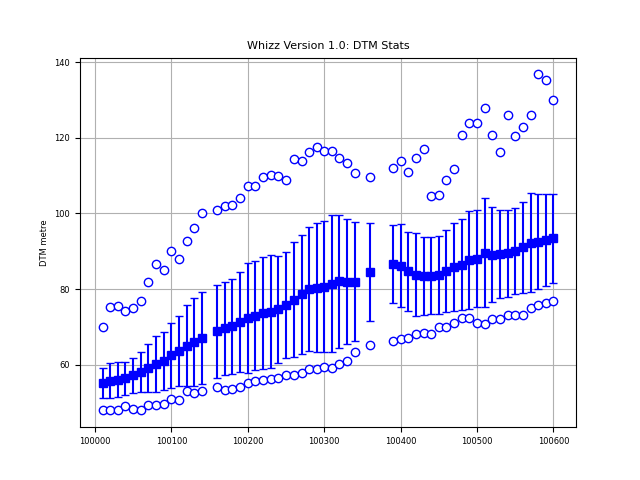

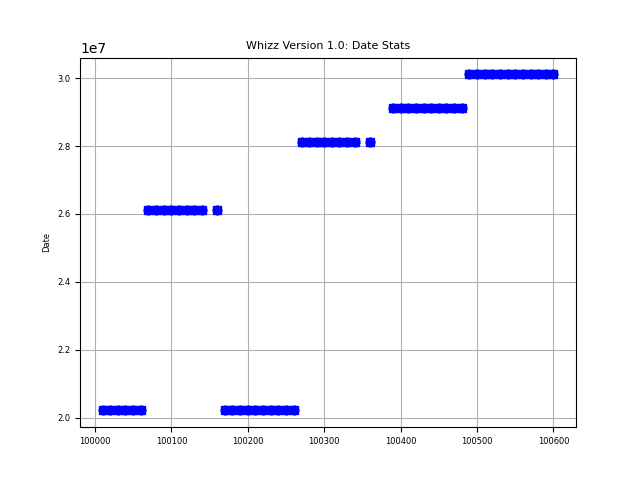

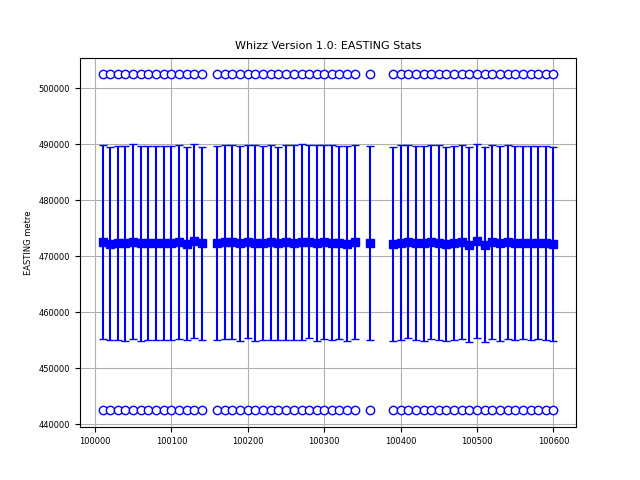

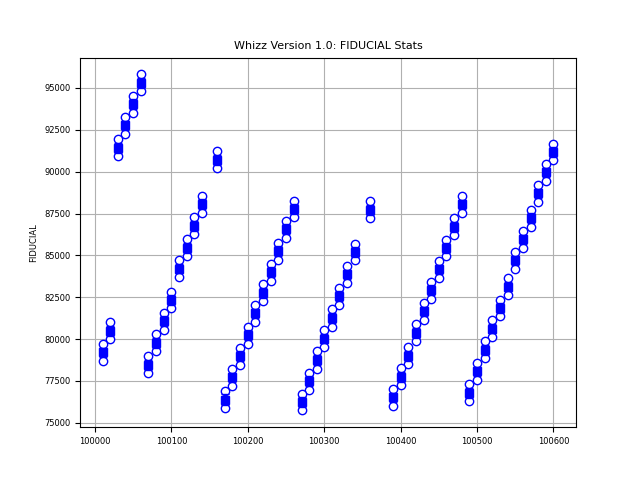

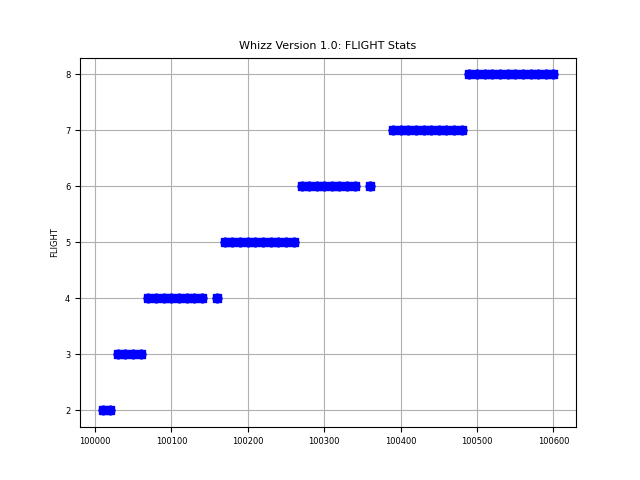

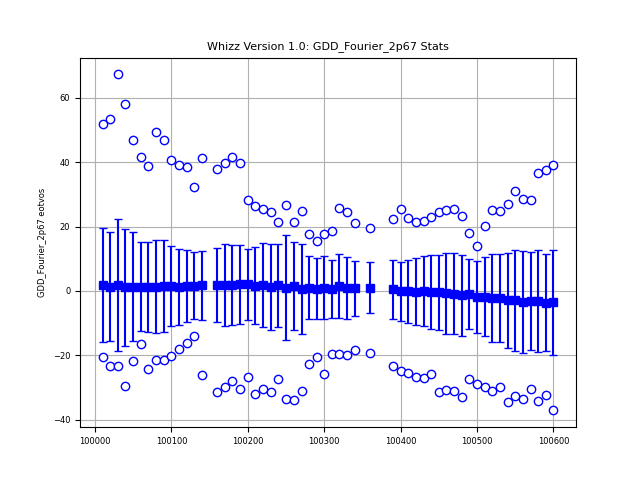

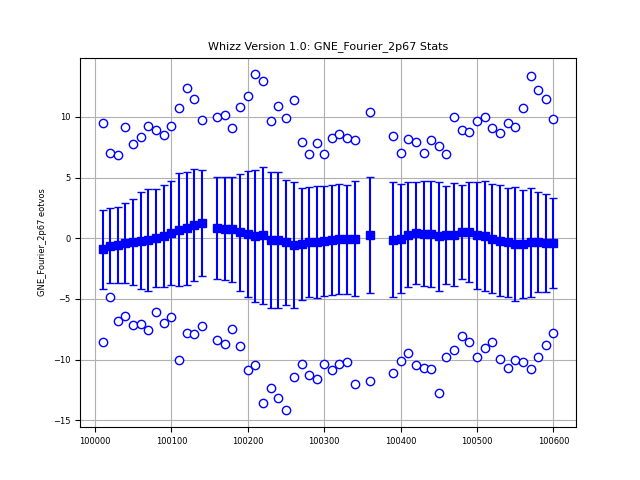

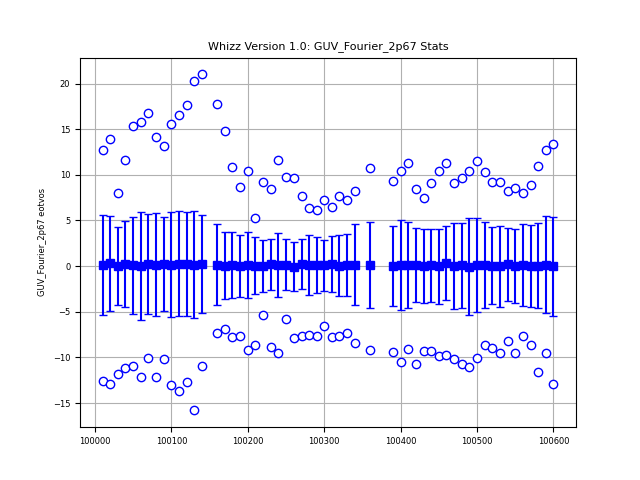

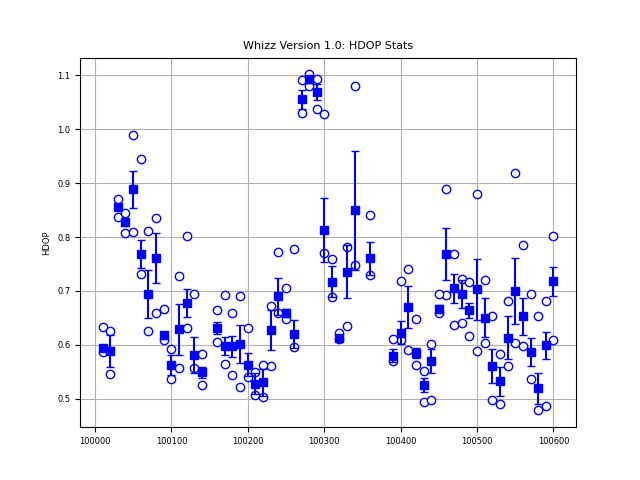

/Users/markdransfield/Documents/GitHub/AirGravQC/src/qualityAnalysis.py:3835: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  ax = fig.add_subplot(1,1,1)


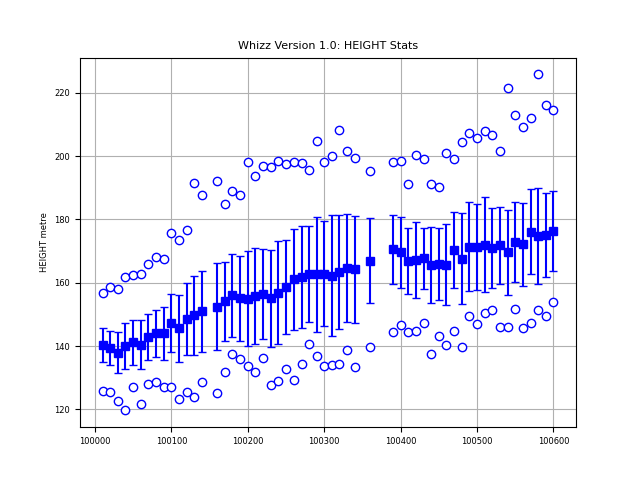

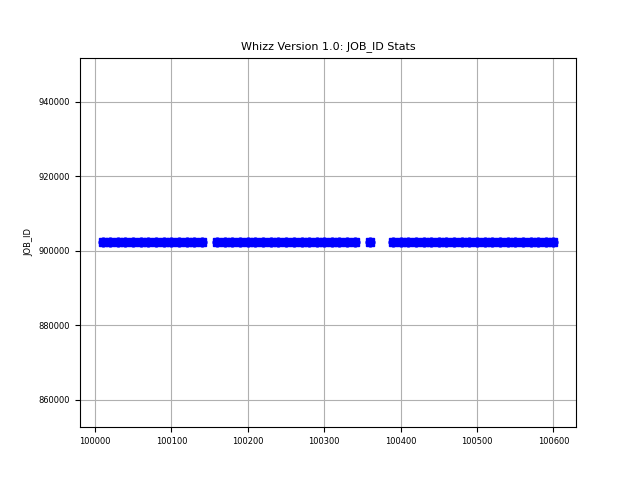

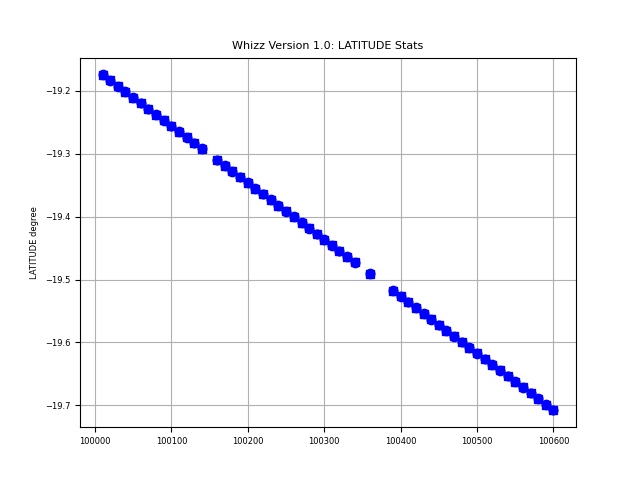

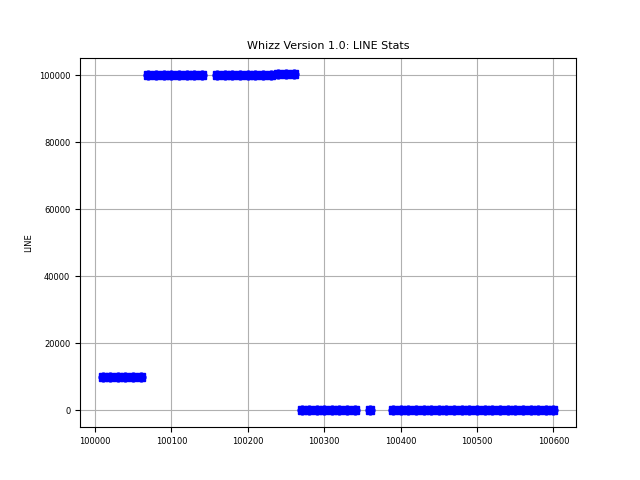

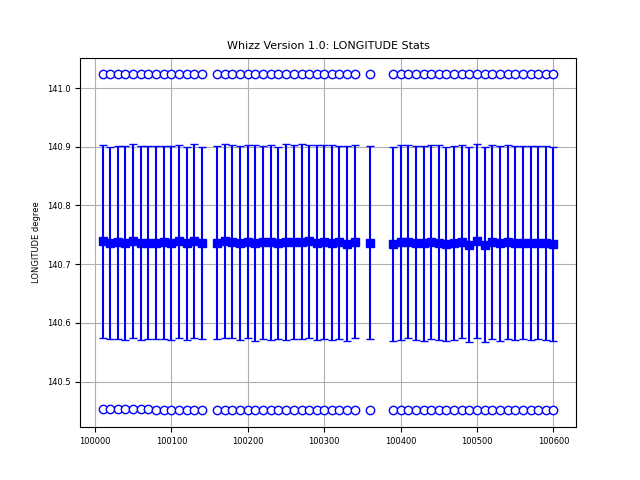

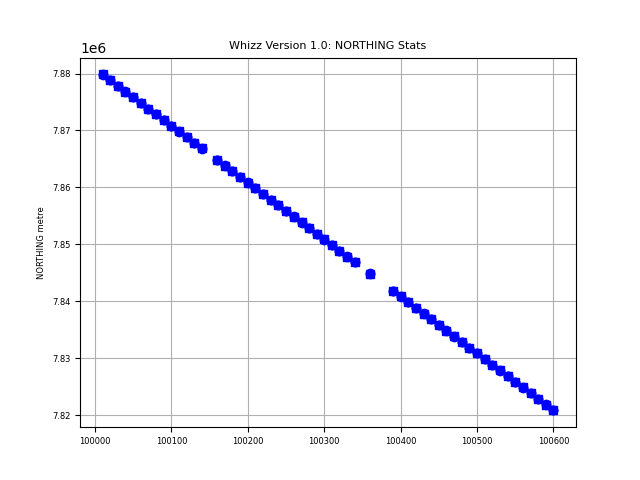

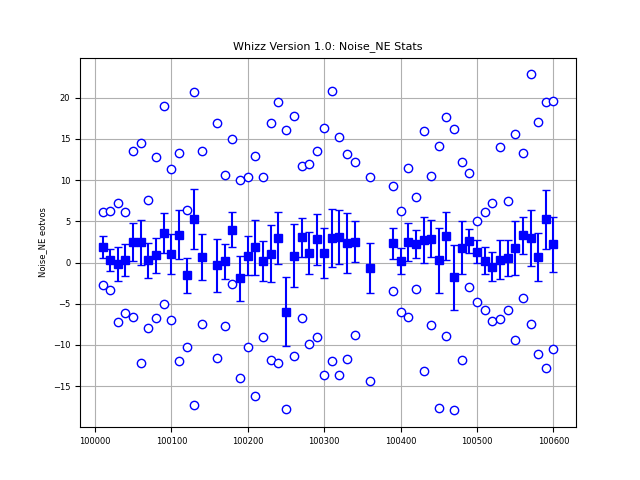

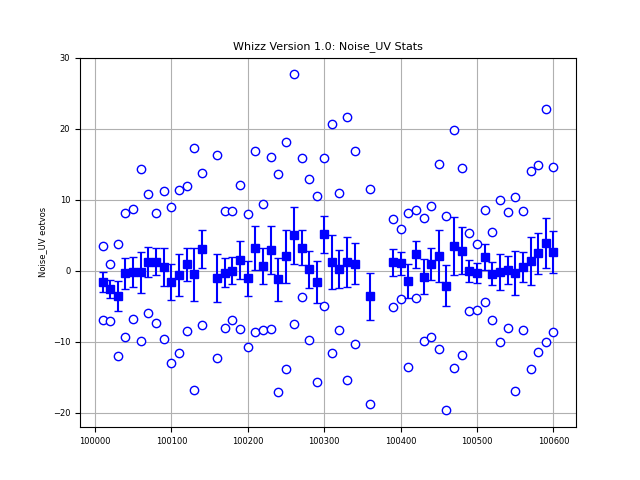

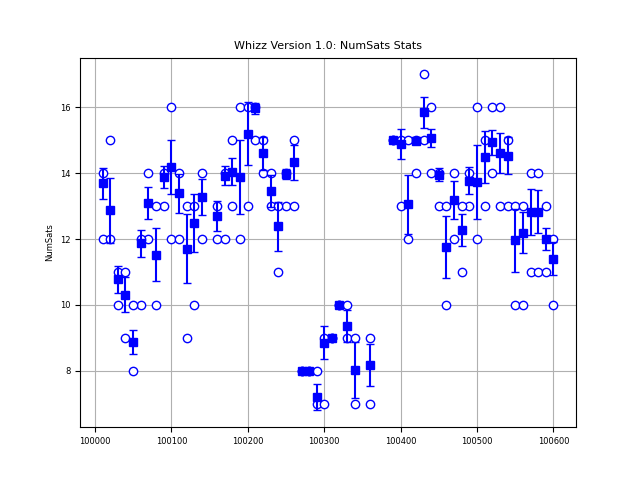

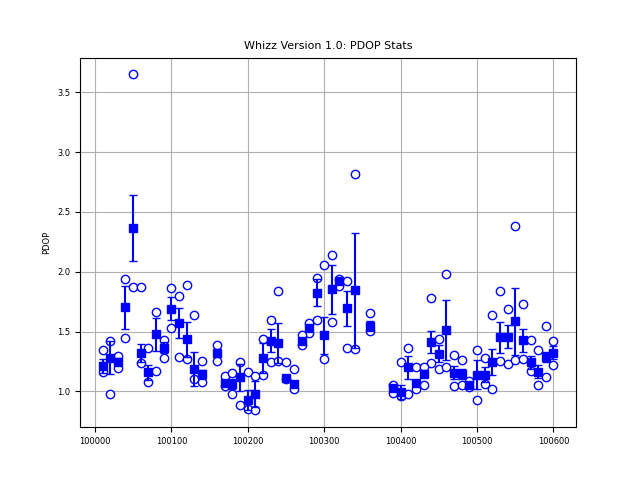

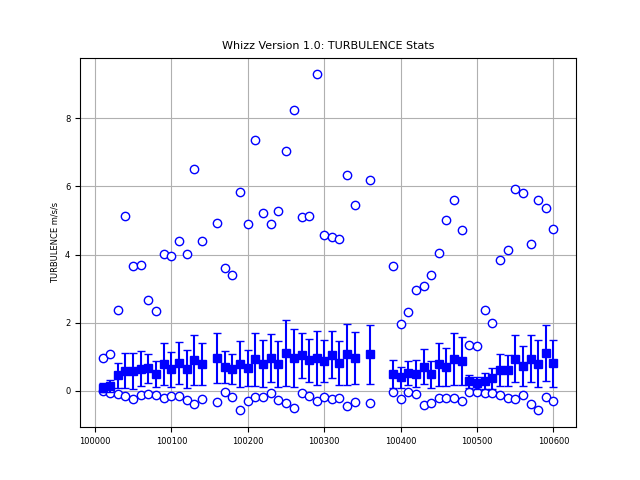

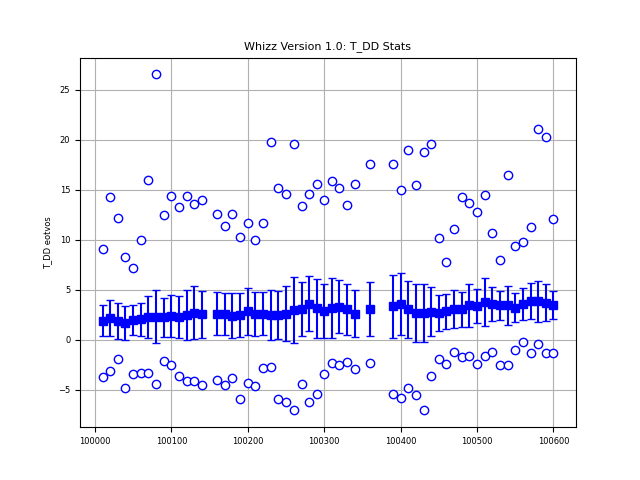

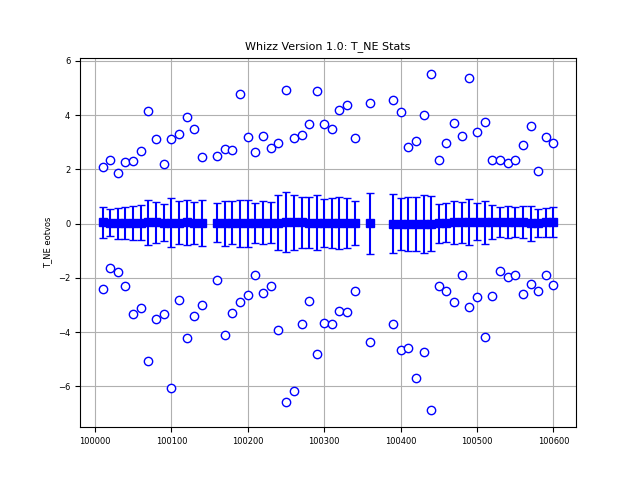

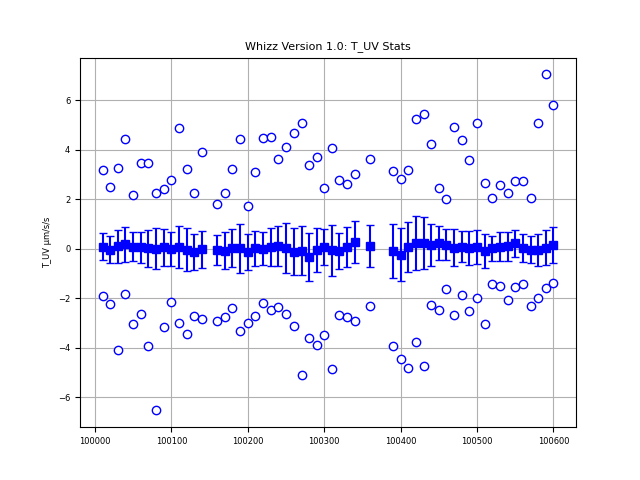

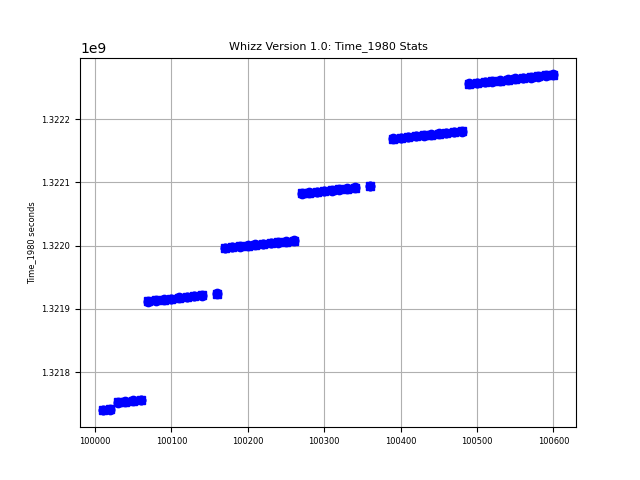

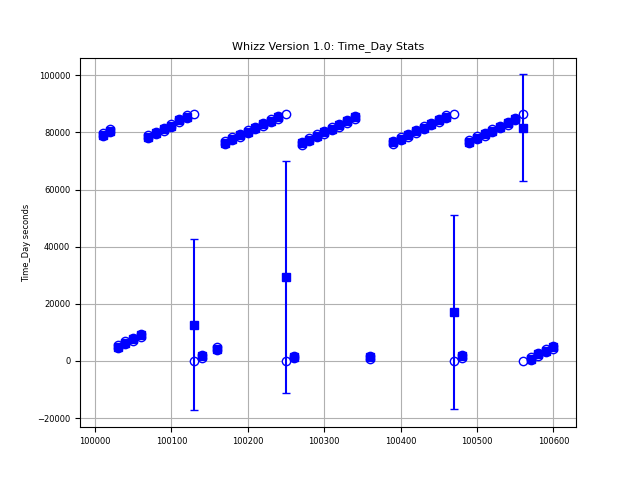

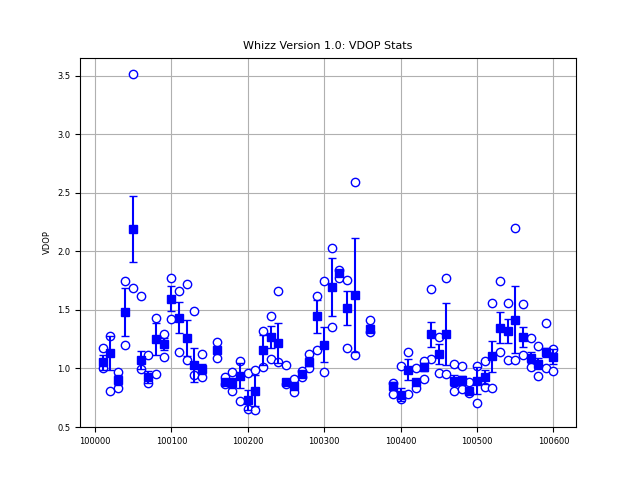

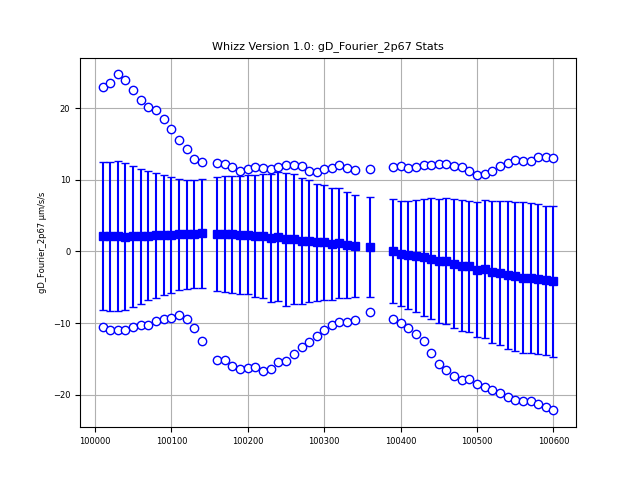

In [35]:
qc.allChanStats(dh, ['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67', 'Bearing',
                     'CLEARANCE', 'DTM', 'Date', 'EASTING', 'FIDUCIAL', 'FLIGHT', 'GDD_Fourier_2p67',
                     'GNE_Fourier_2p67', 'GUV_Fourier_2p67', 'HDOP', 'HEIGHT', 'JOB_ID', 'LATITUDE',
                     'LINE', 'LONGITUDE', 'NORTHING', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP',
                     'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'Time_1980', 'Time_Day', 'VDOP', 'gD_Fourier_2p67'])

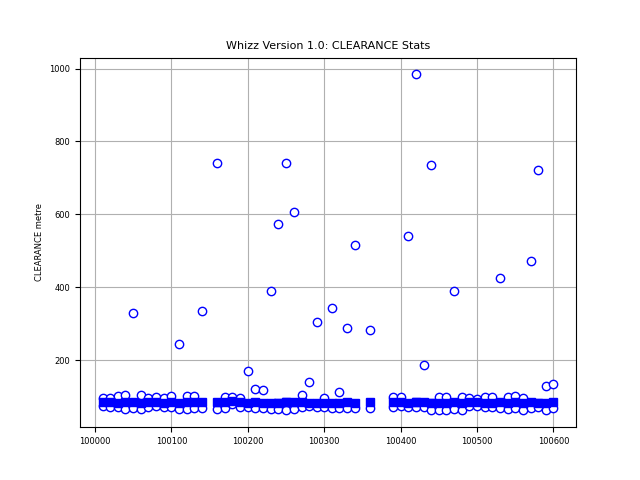

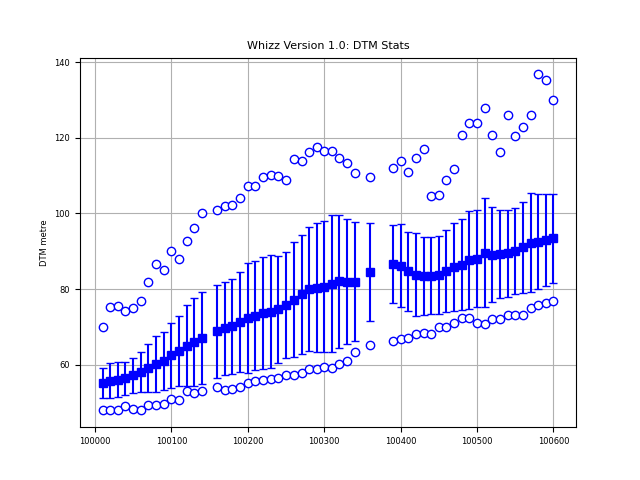

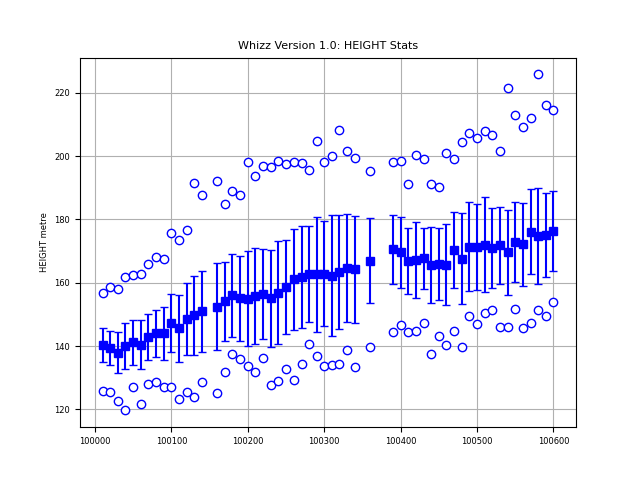

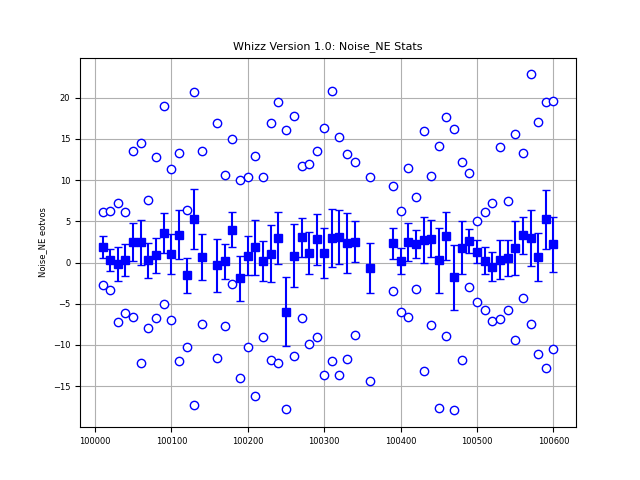

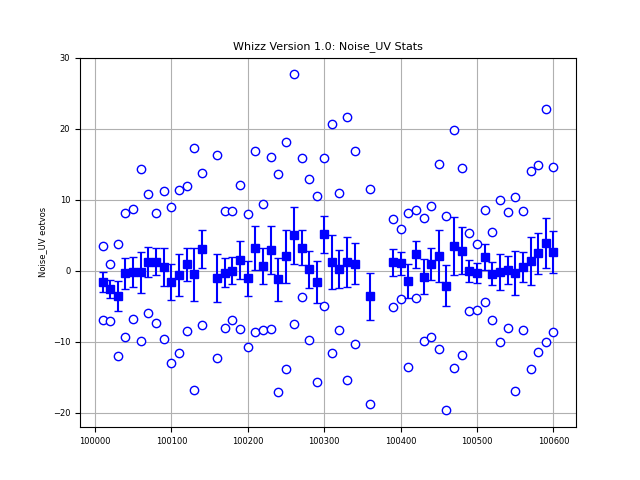

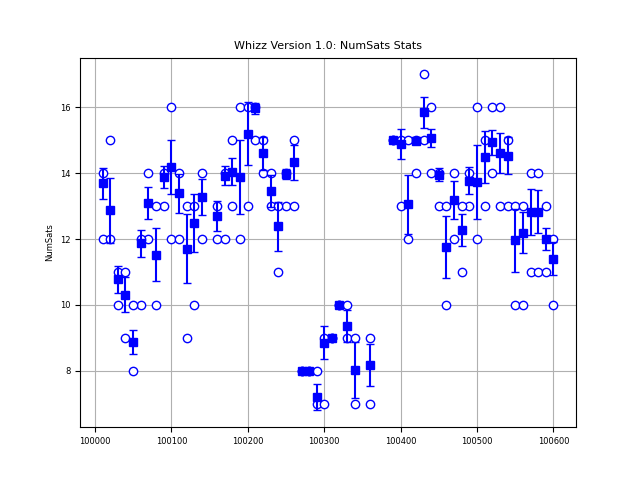

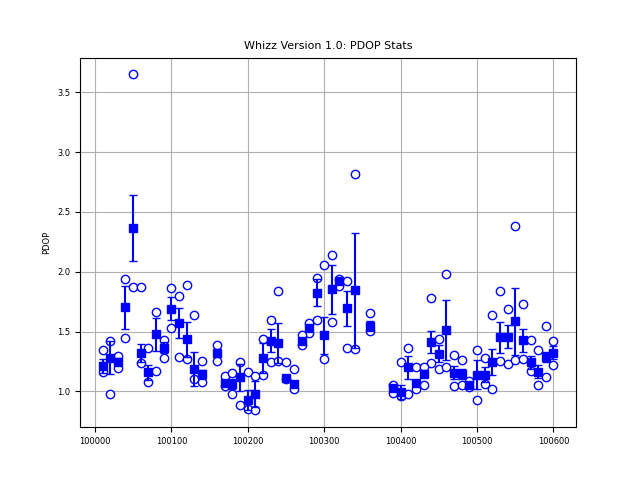

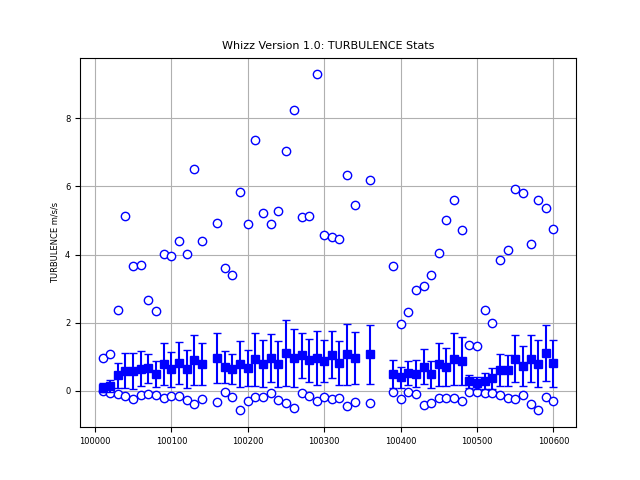

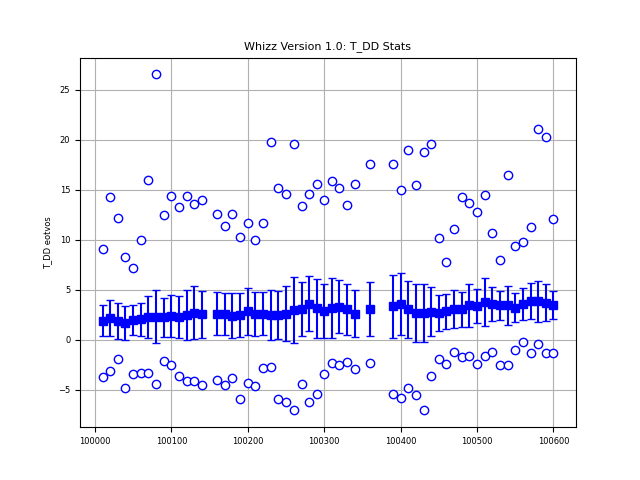

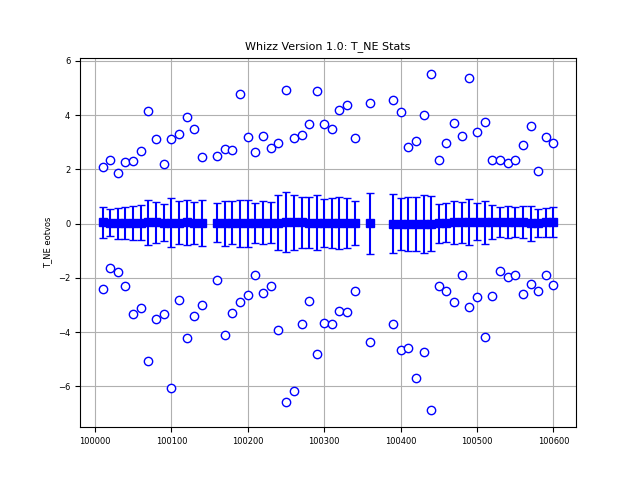

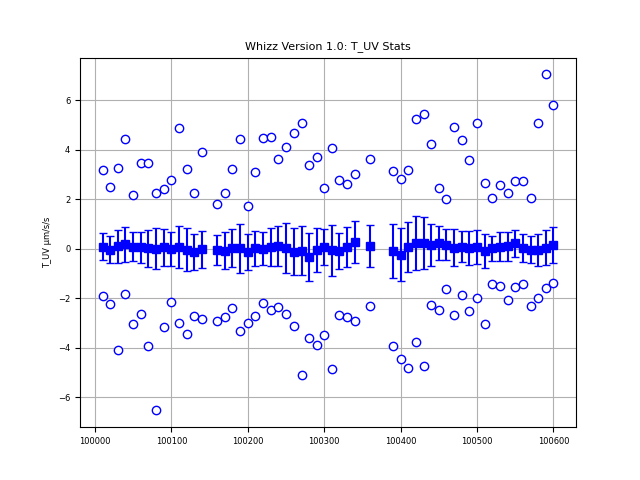

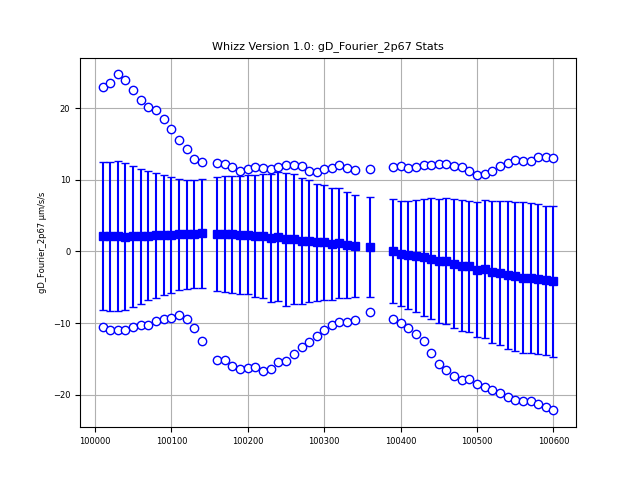

In [5]:
qc.allChanStats(dh, ['CLEARANCE', 'DTM', 'HEIGHT', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP',
                     'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'gD_Fourier_2p67'])

#### Delivered Grids
<div class="alert alert-block alert-info">
NA
<div>

*For Canobie, there was no requirement for grids of field data to be delivered and none were.*

> The Deed does not have specifications on the quality of gridded field data but grids are a quick and easy way to spot any artefacts in the data. So they are useful in checking for "best practice".

> The function `checkErsHeaders()` is useful when there are supplied grids.

> In any case, I always generate grids from the located data.

In [ ]:
# qc.checkErsHeaders(ersp)

#### Generated Grids
<div class="alert alert-block alert-success">
PASS
<div>

*There are no Deed specifications on the grids except "best practice".*

All the grids look okay and there are no serious artefacts.

> I grid and image almost every channel in the database (here I have omitted only `DATE`). Channels that are directionally dependent have the mean for each line removed ("mr") before gridding. For some channels it is more useful to examine the grid of the first difference along each line ("d1").

> It might be useful to comment on some particular images.

Gridding and imaging Bearing
Total number of fids in whizz file = 450948.
Processing (x, y, z) = (EASTING, NORTHING, Bearing). Bearing in degrees.
Data points cover region: [ 442442.  502444. 7820809. 7879855.]
z range (1st to 99th percentile) (-2.3, 2.362)


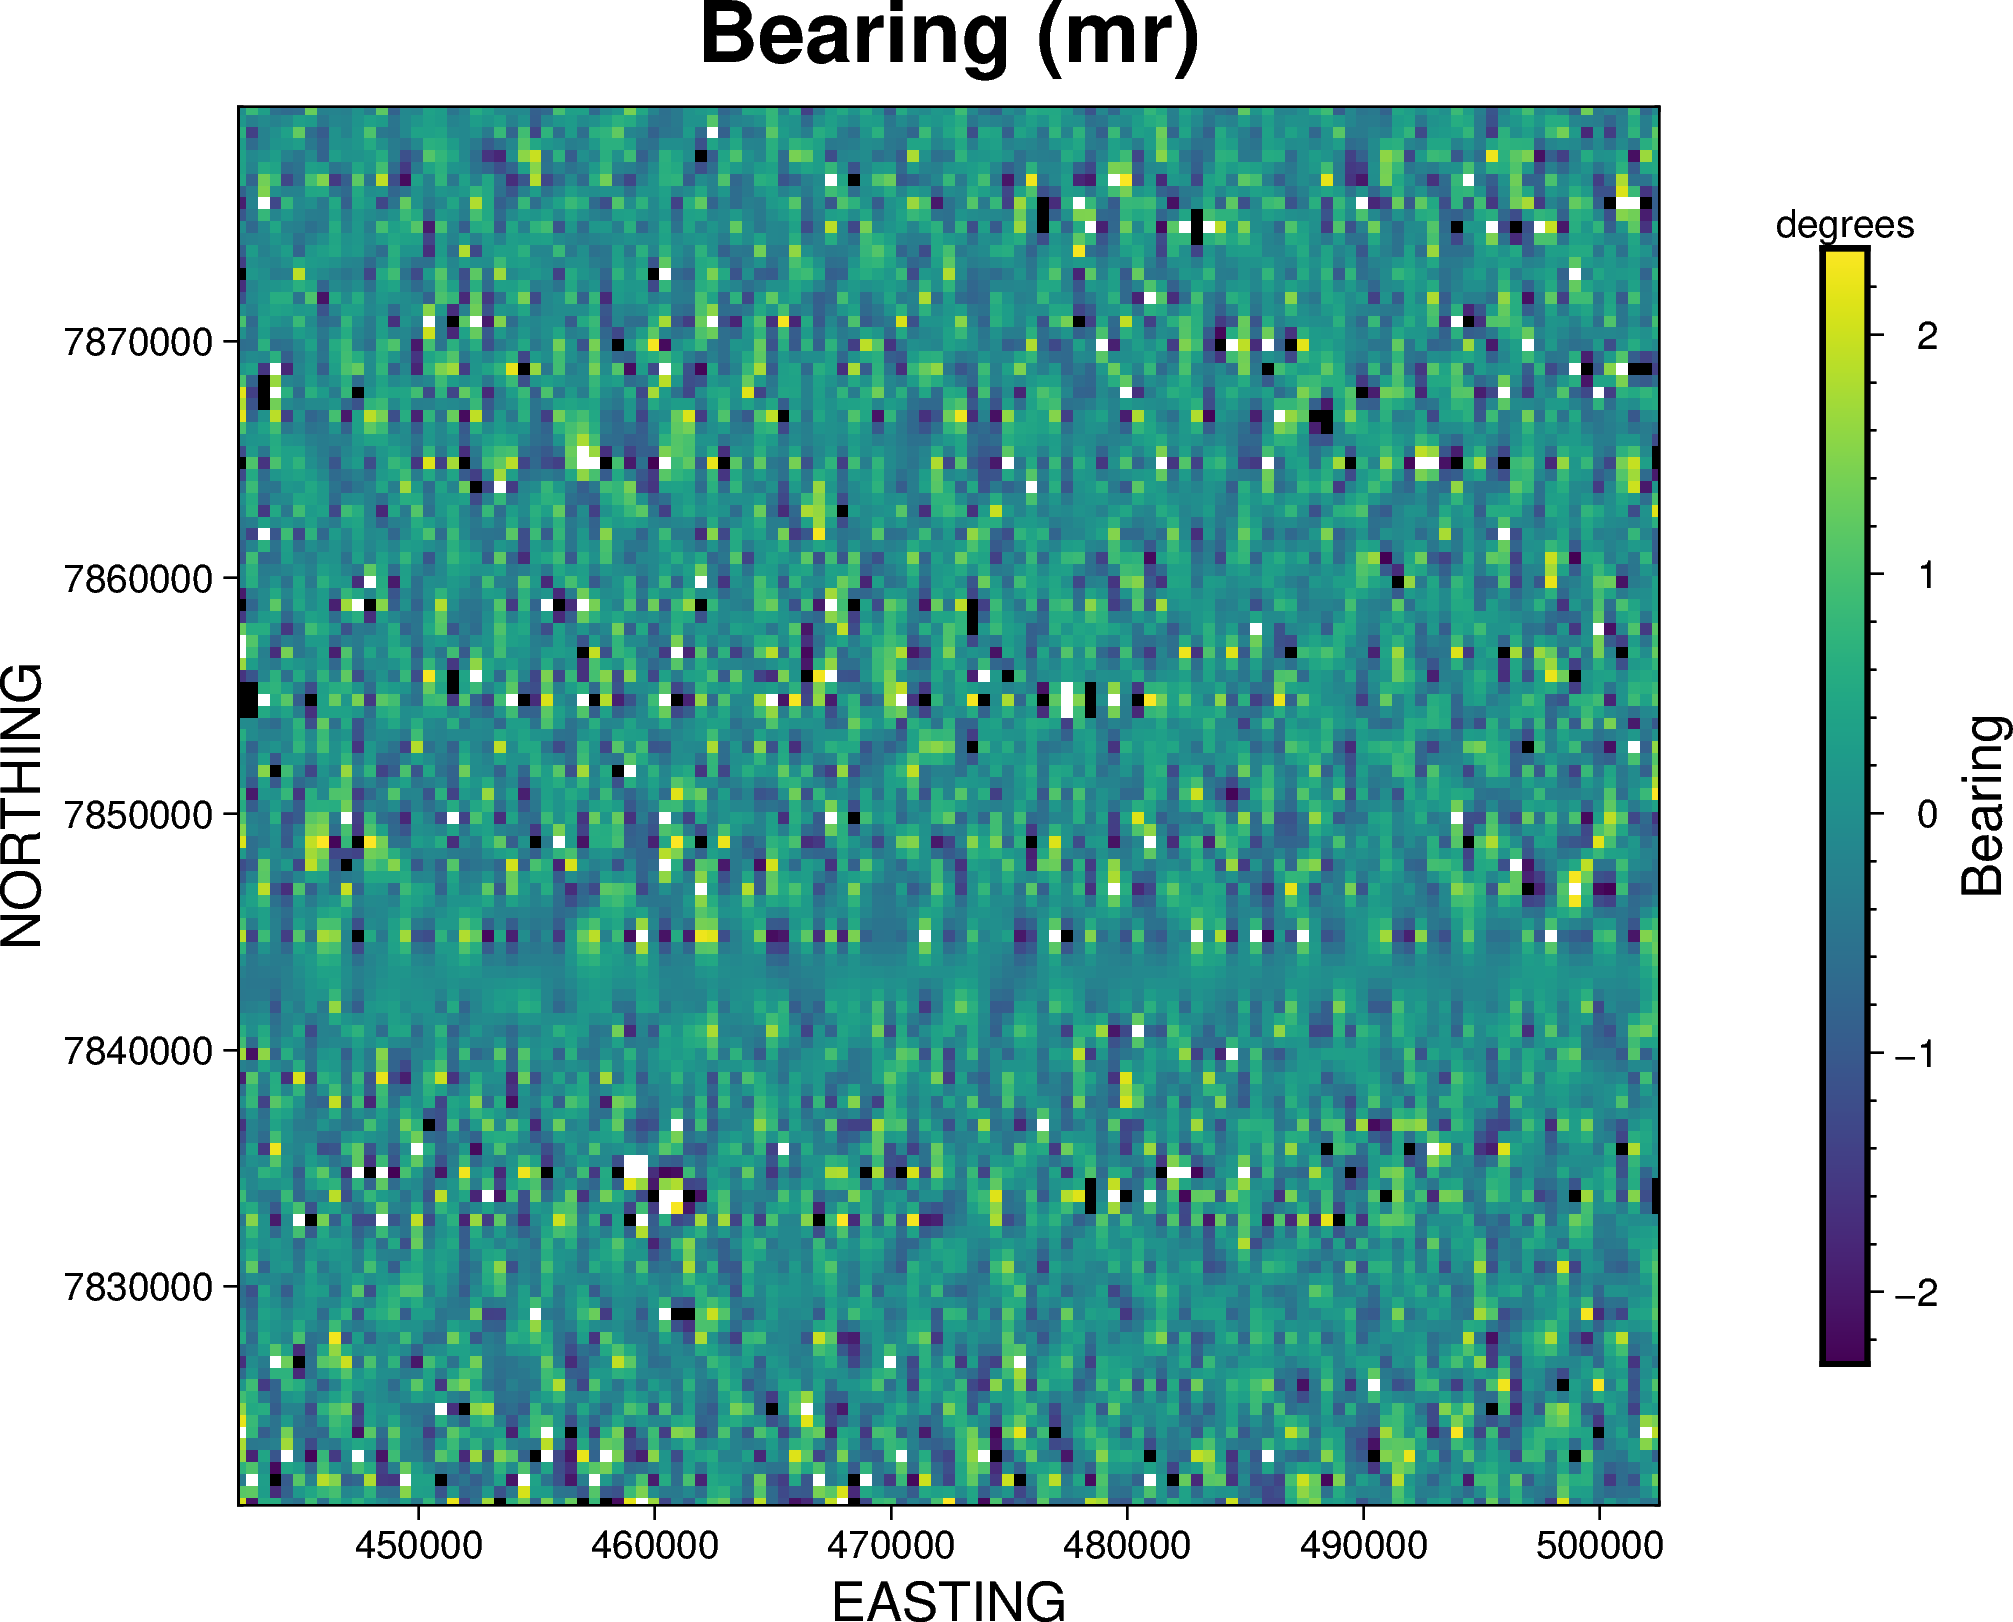

Gridding and imaging CLEARANCE
Total number of fids in whizz file = 450948.
Processing (x, y, z) = (EASTING, NORTHING, CLEARANCE). CLEARANCE in metre.
Data points cover region: [ 442442.  502444. 7820809. 7879855.]
z range (1st to 99th percentile) (73.26, 92.82)


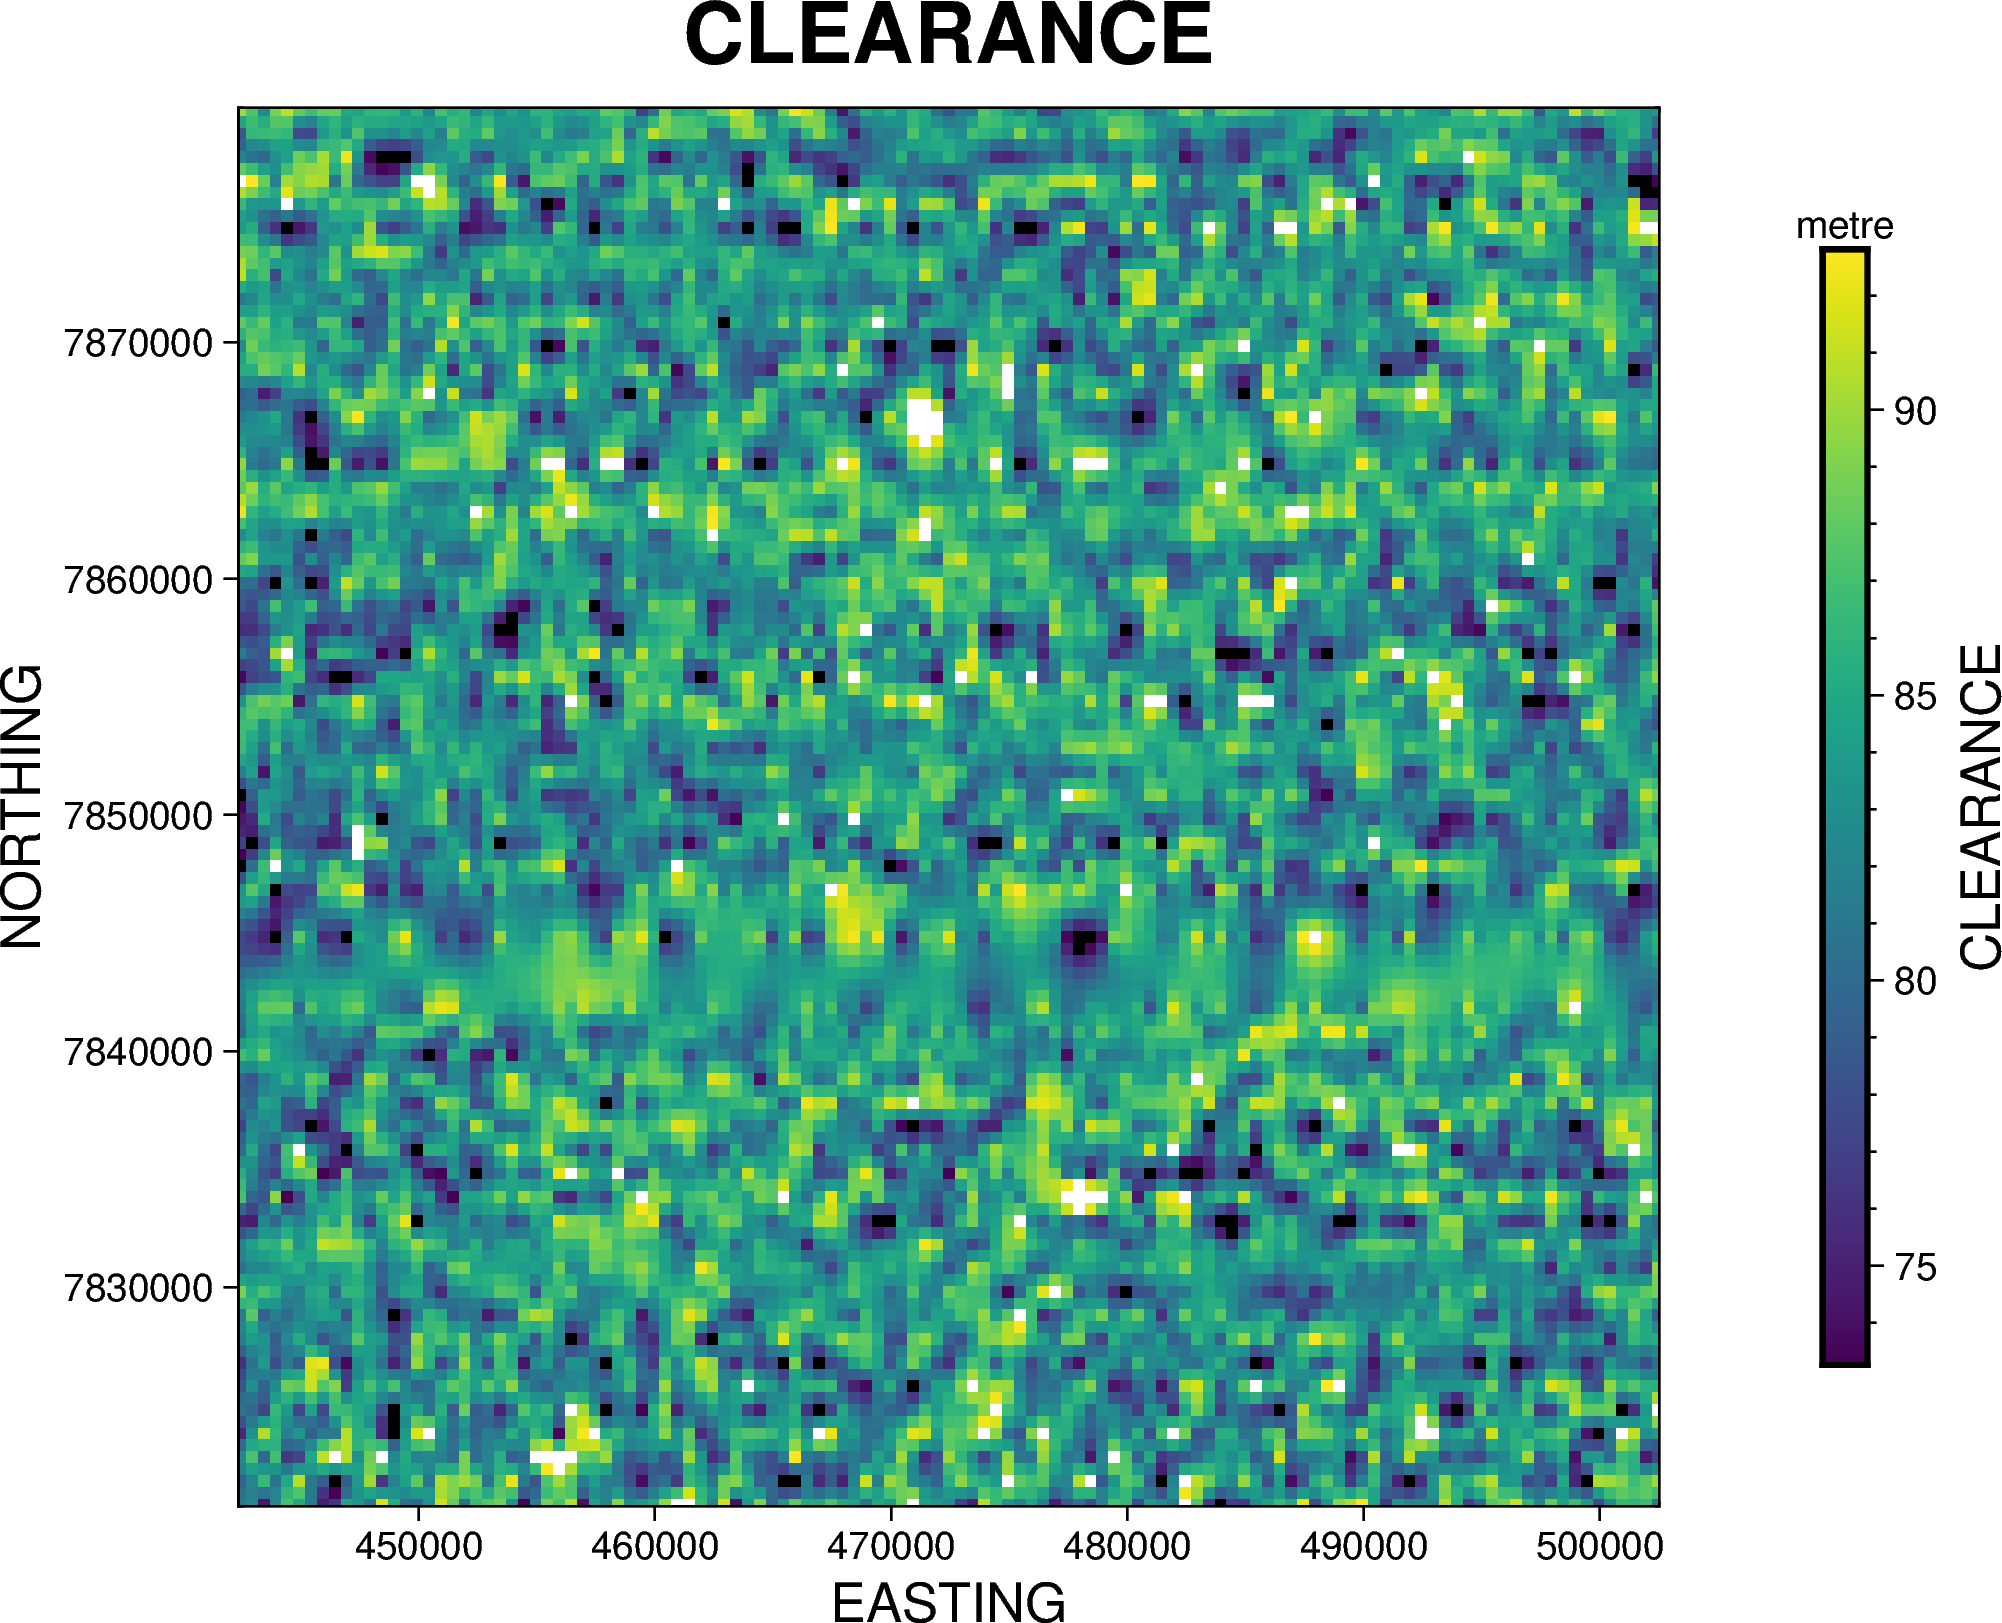

Gridding and imaging DTM
Total number of fids in whizz file = 450948.
Processing (x, y, z) = (EASTING, NORTHING, DTM). DTM in metre.
Data points cover region: [ 442442.  502444. 7820809. 7879855.]
z range (1st to 99th percentile) (51.86, 117.4)


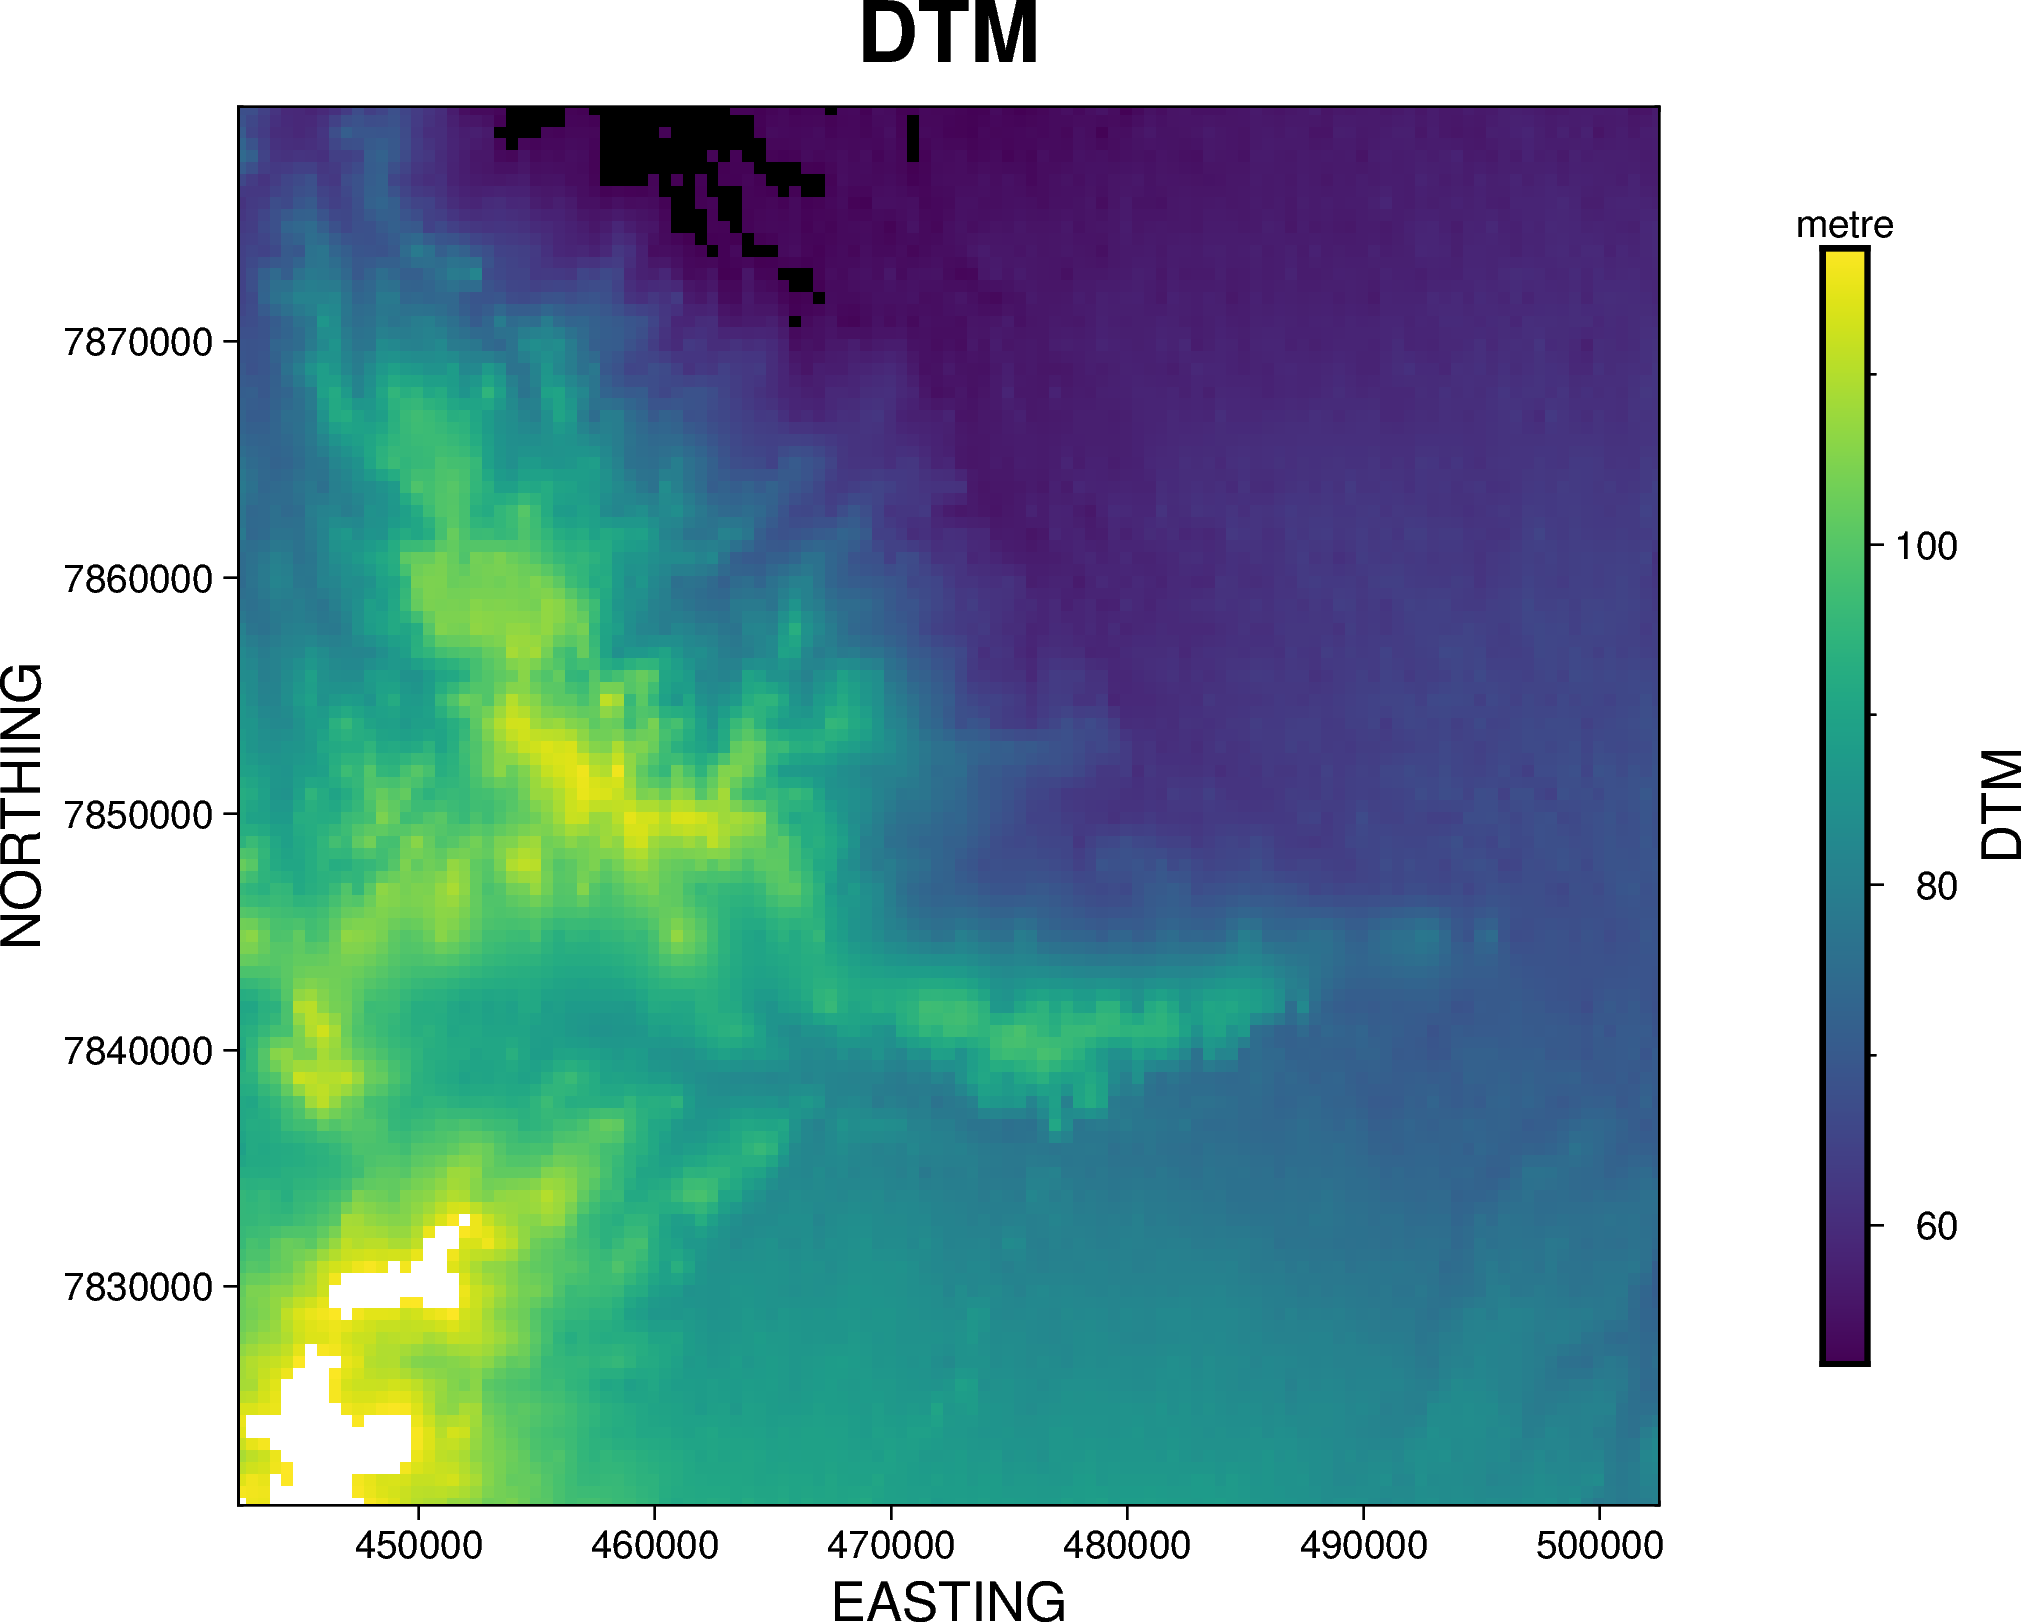

Gridding and imaging FLIGHT
Total number of fids in whizz file = 450948.
Processing (x, y, z) = (EASTING, NORTHING, FLIGHT). FLIGHT in -.
Data points cover region: [ 442442.  502444. 7820809. 7879855.]


surface [WARNING]: Input data lie exactly on a plane.


z range (1st to 99th percentile) (0, 0)


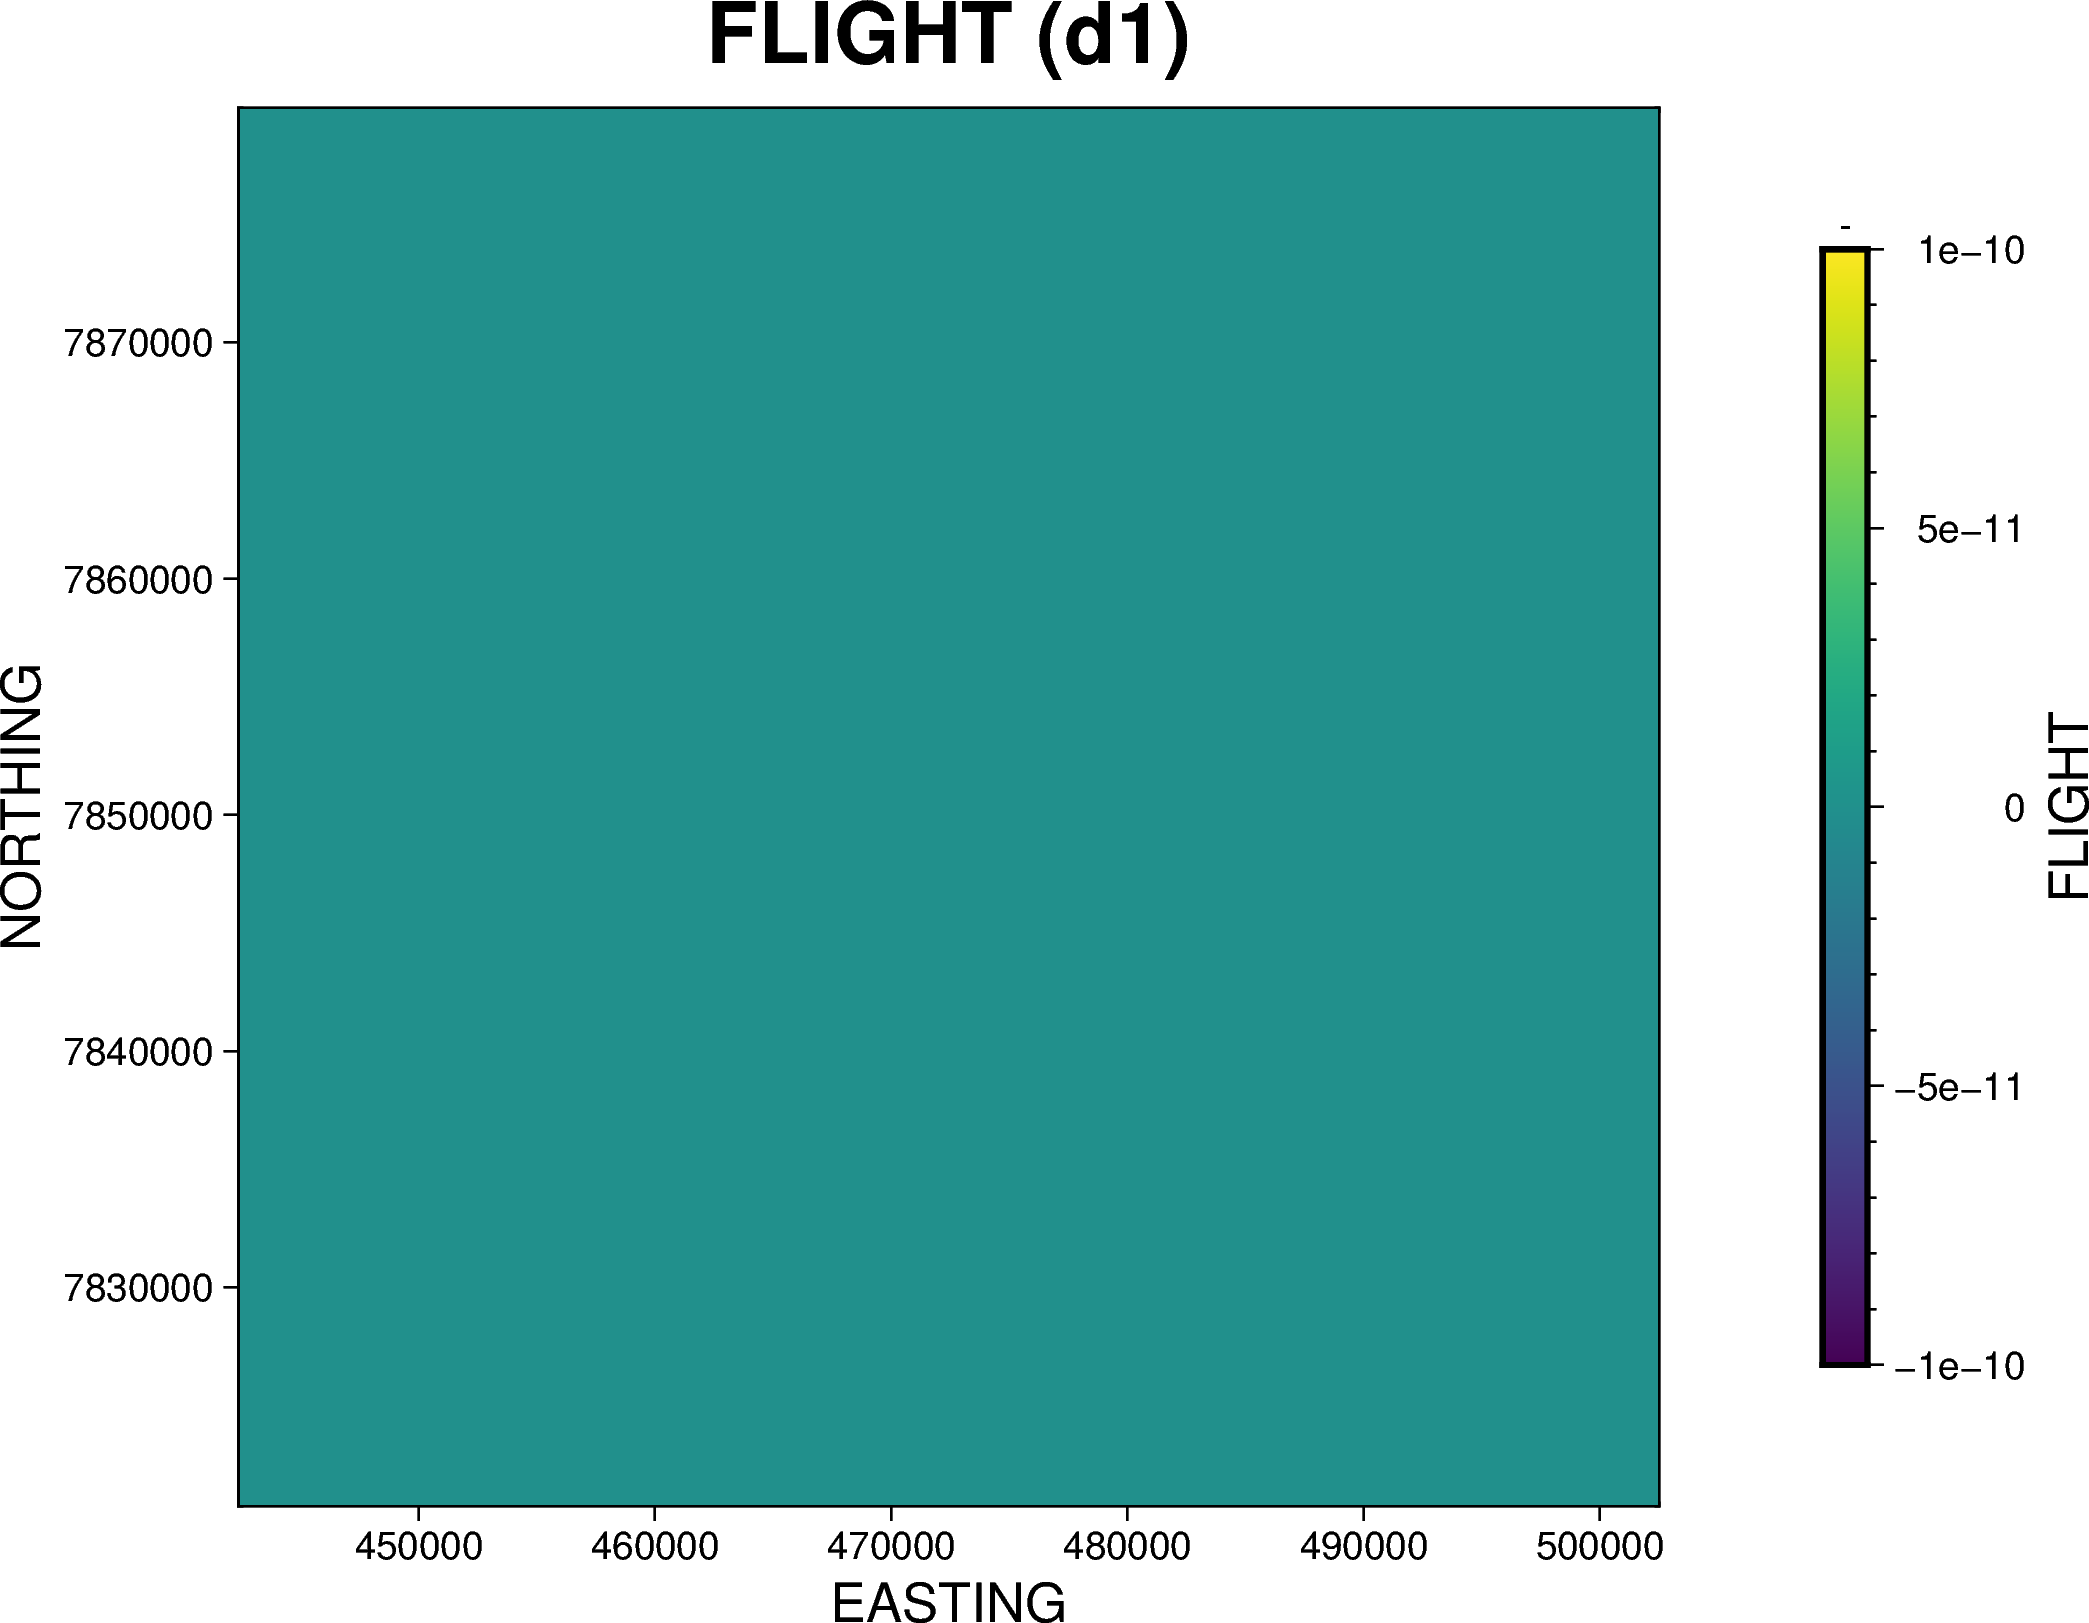

Gridding and imaging GDD_Fourier_2p67
Total number of fids in whizz file = 450948.
Processing (x, y, z) = (EASTING, NORTHING, GDD_Fourier_2p67). GDD_Fourier_2p67 in eotvos.
Data points cover region: [ 442442.  502444. 7820809. 7879855.]
z range (1st to 99th percentile) (-28.97, 37.55)


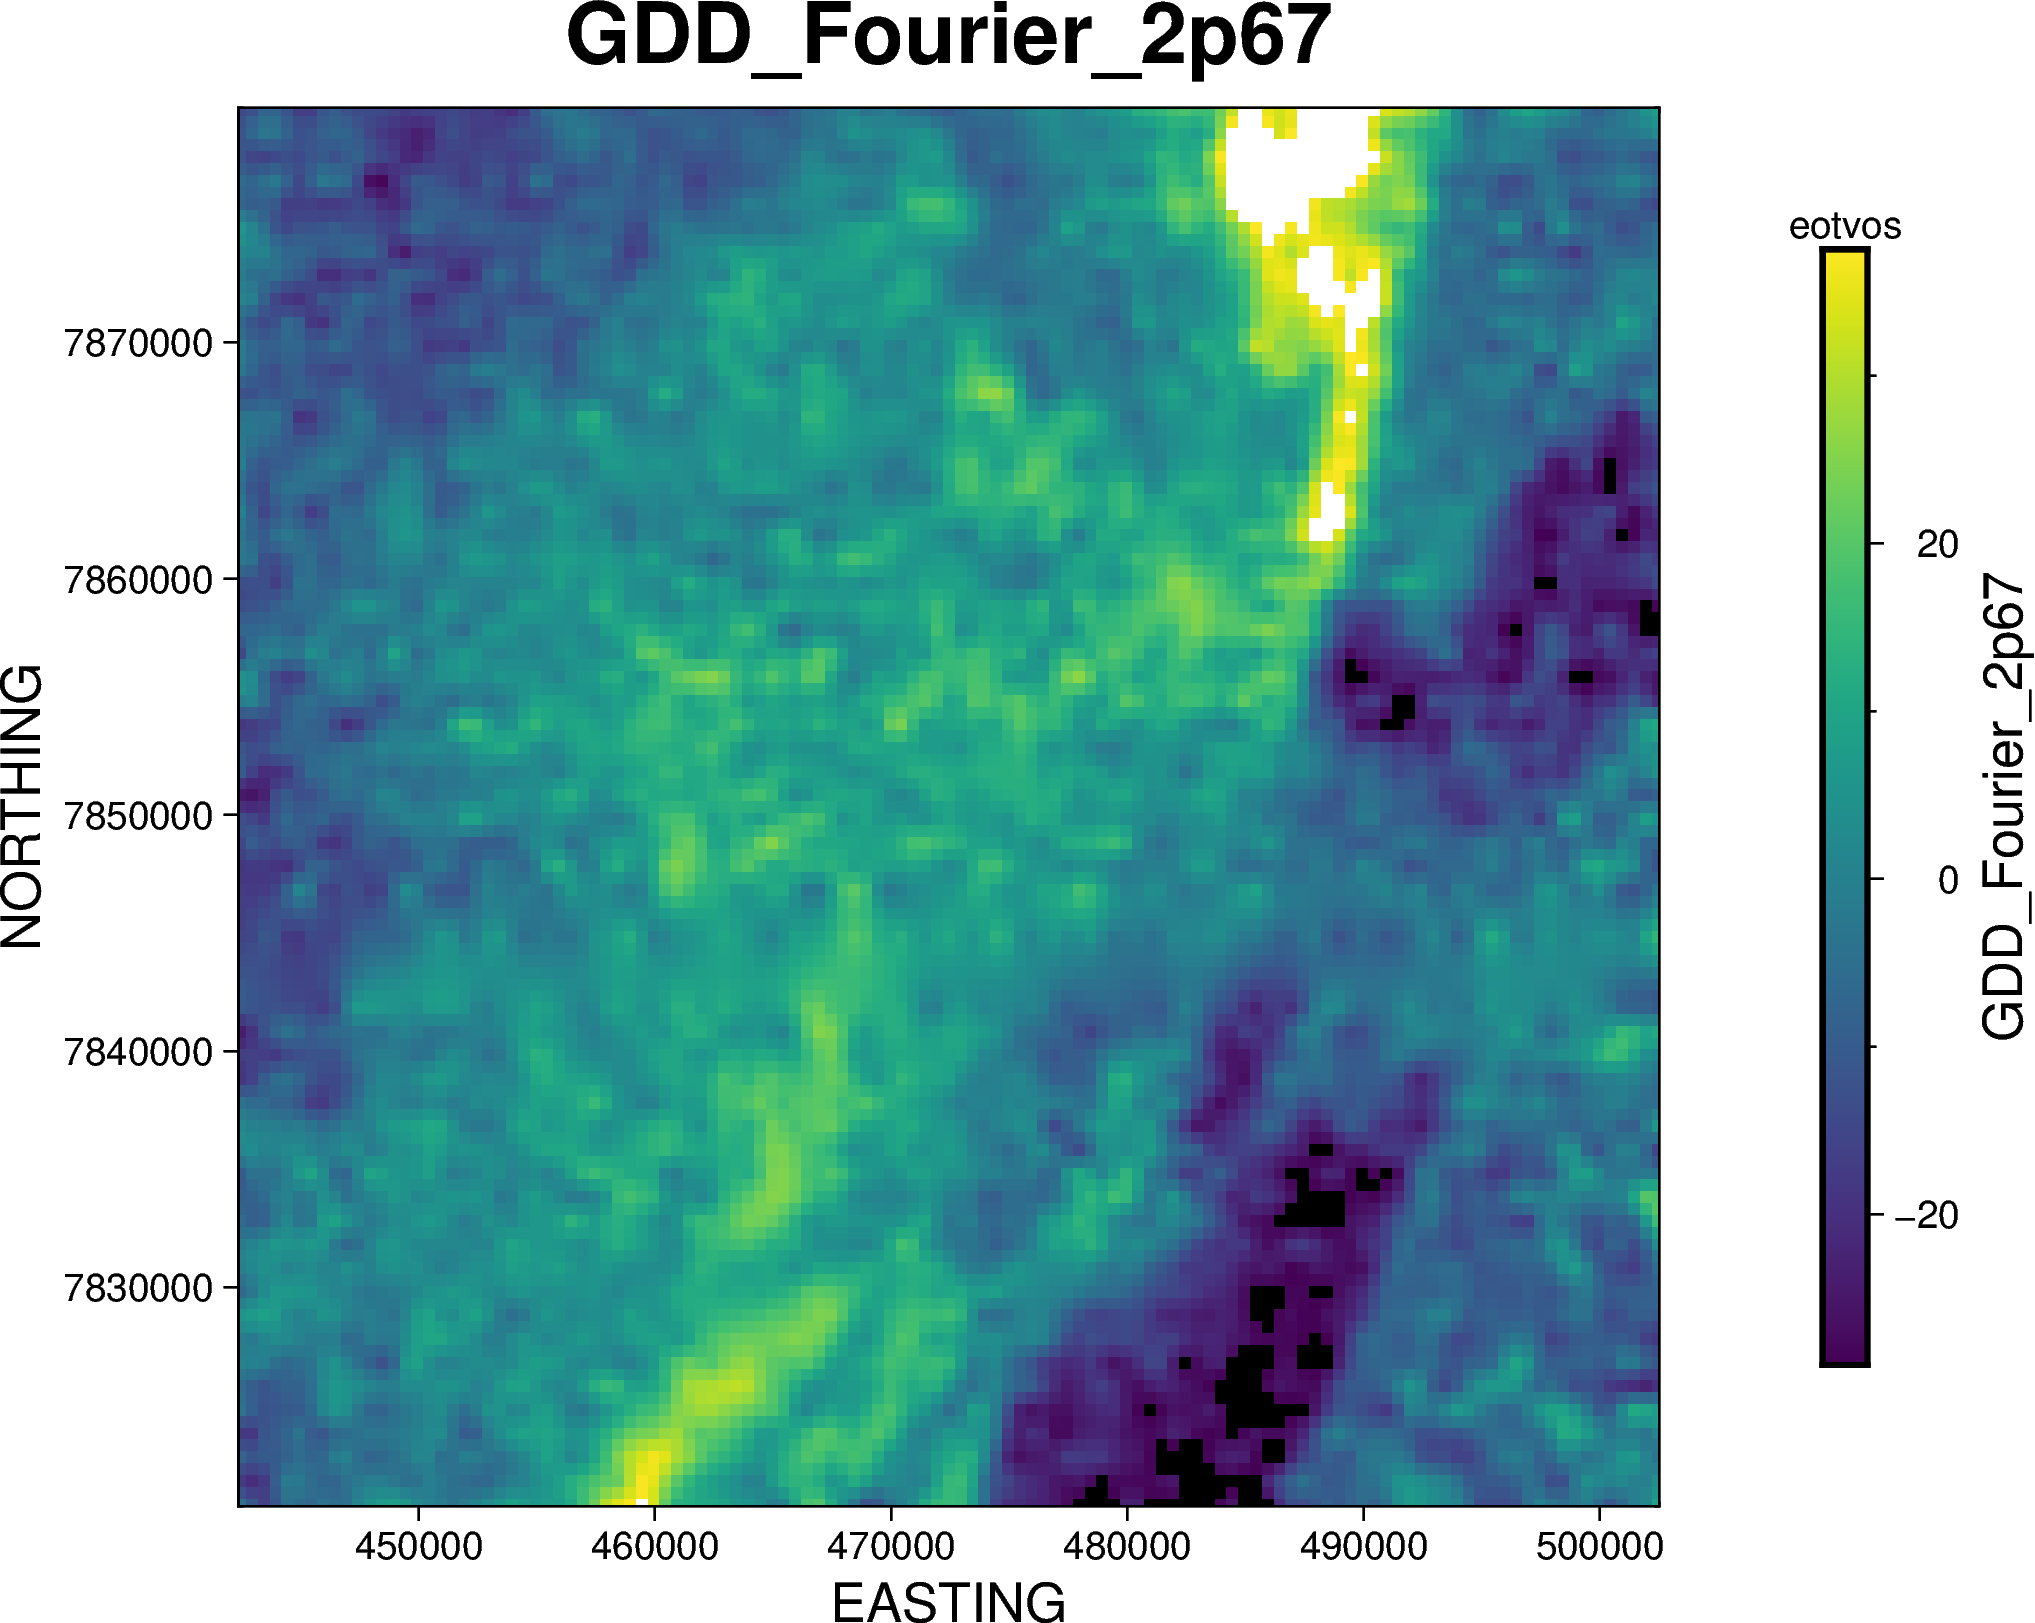

Gridding and imaging NumSats
Total number of fids in whizz file = 450948.
Processing (x, y, z) = (EASTING, NORTHING, NumSats). NumSats in -.
Data points cover region: [ 442442.  502444. 7820809. 7879855.]
z range (1st to 99th percentile) (6.946, 16.03)


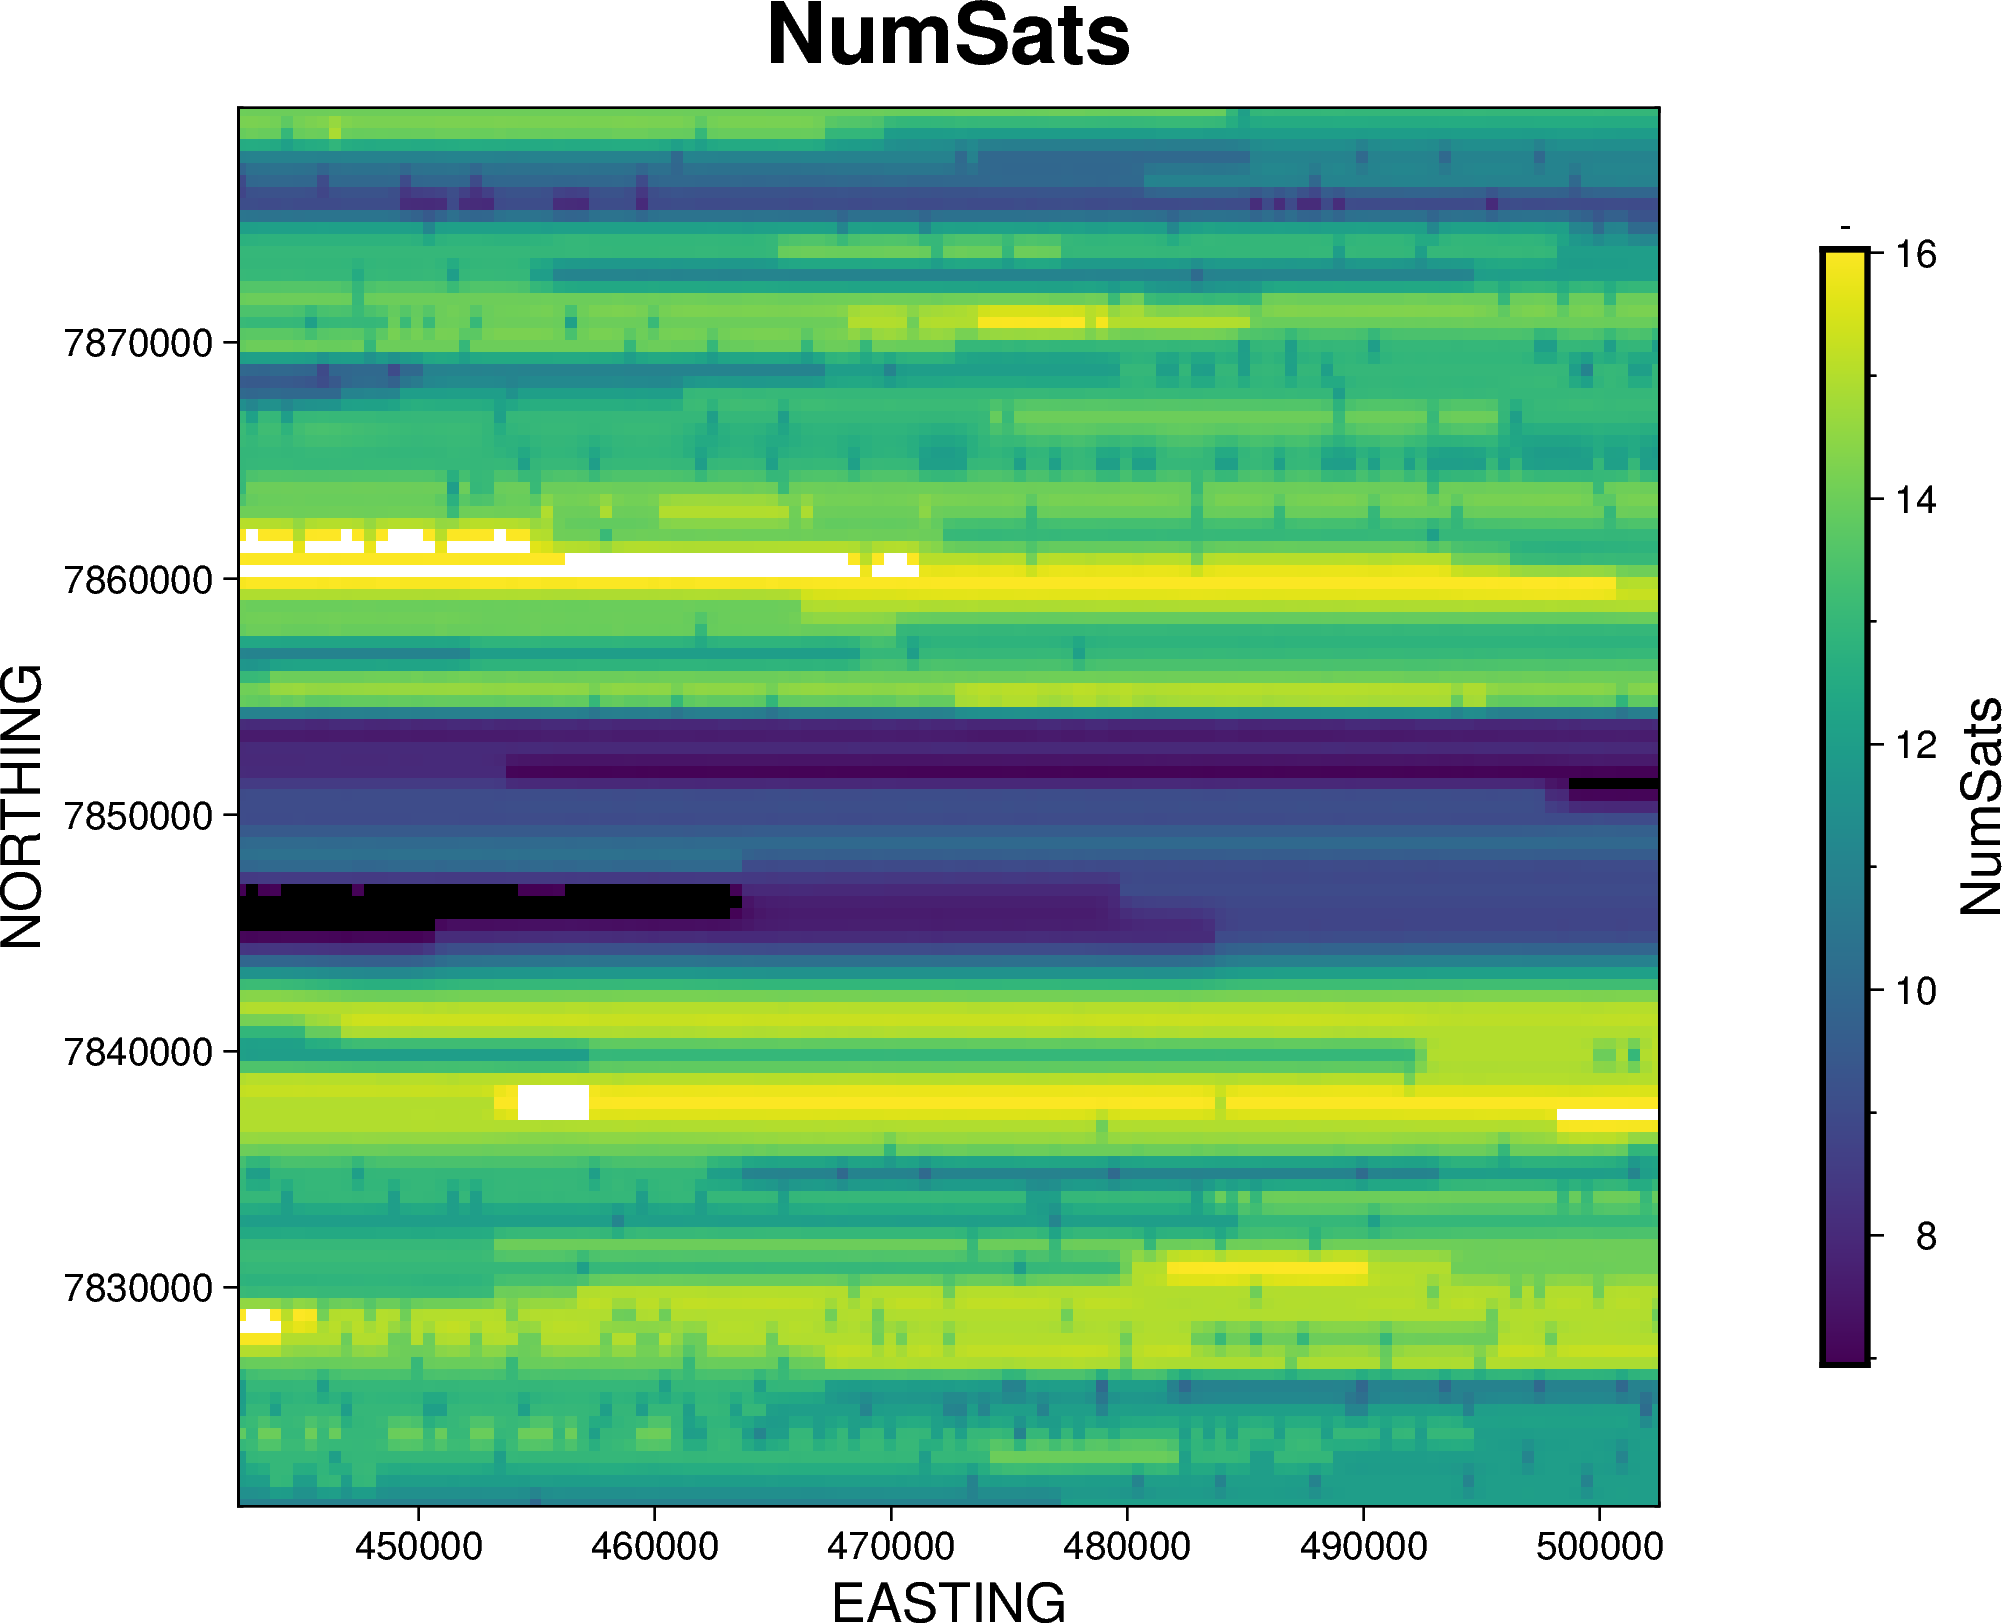

Gridding and imaging T_DD
Total number of fids in whizz file = 450948.
Processing (x, y, z) = (EASTING, NORTHING, T_DD). T_DD in eotvos.
Data points cover region: [ 442442.  502444. 7820809. 7879855.]
z range (1st to 99th percentile) (-0.6069, 9.098)


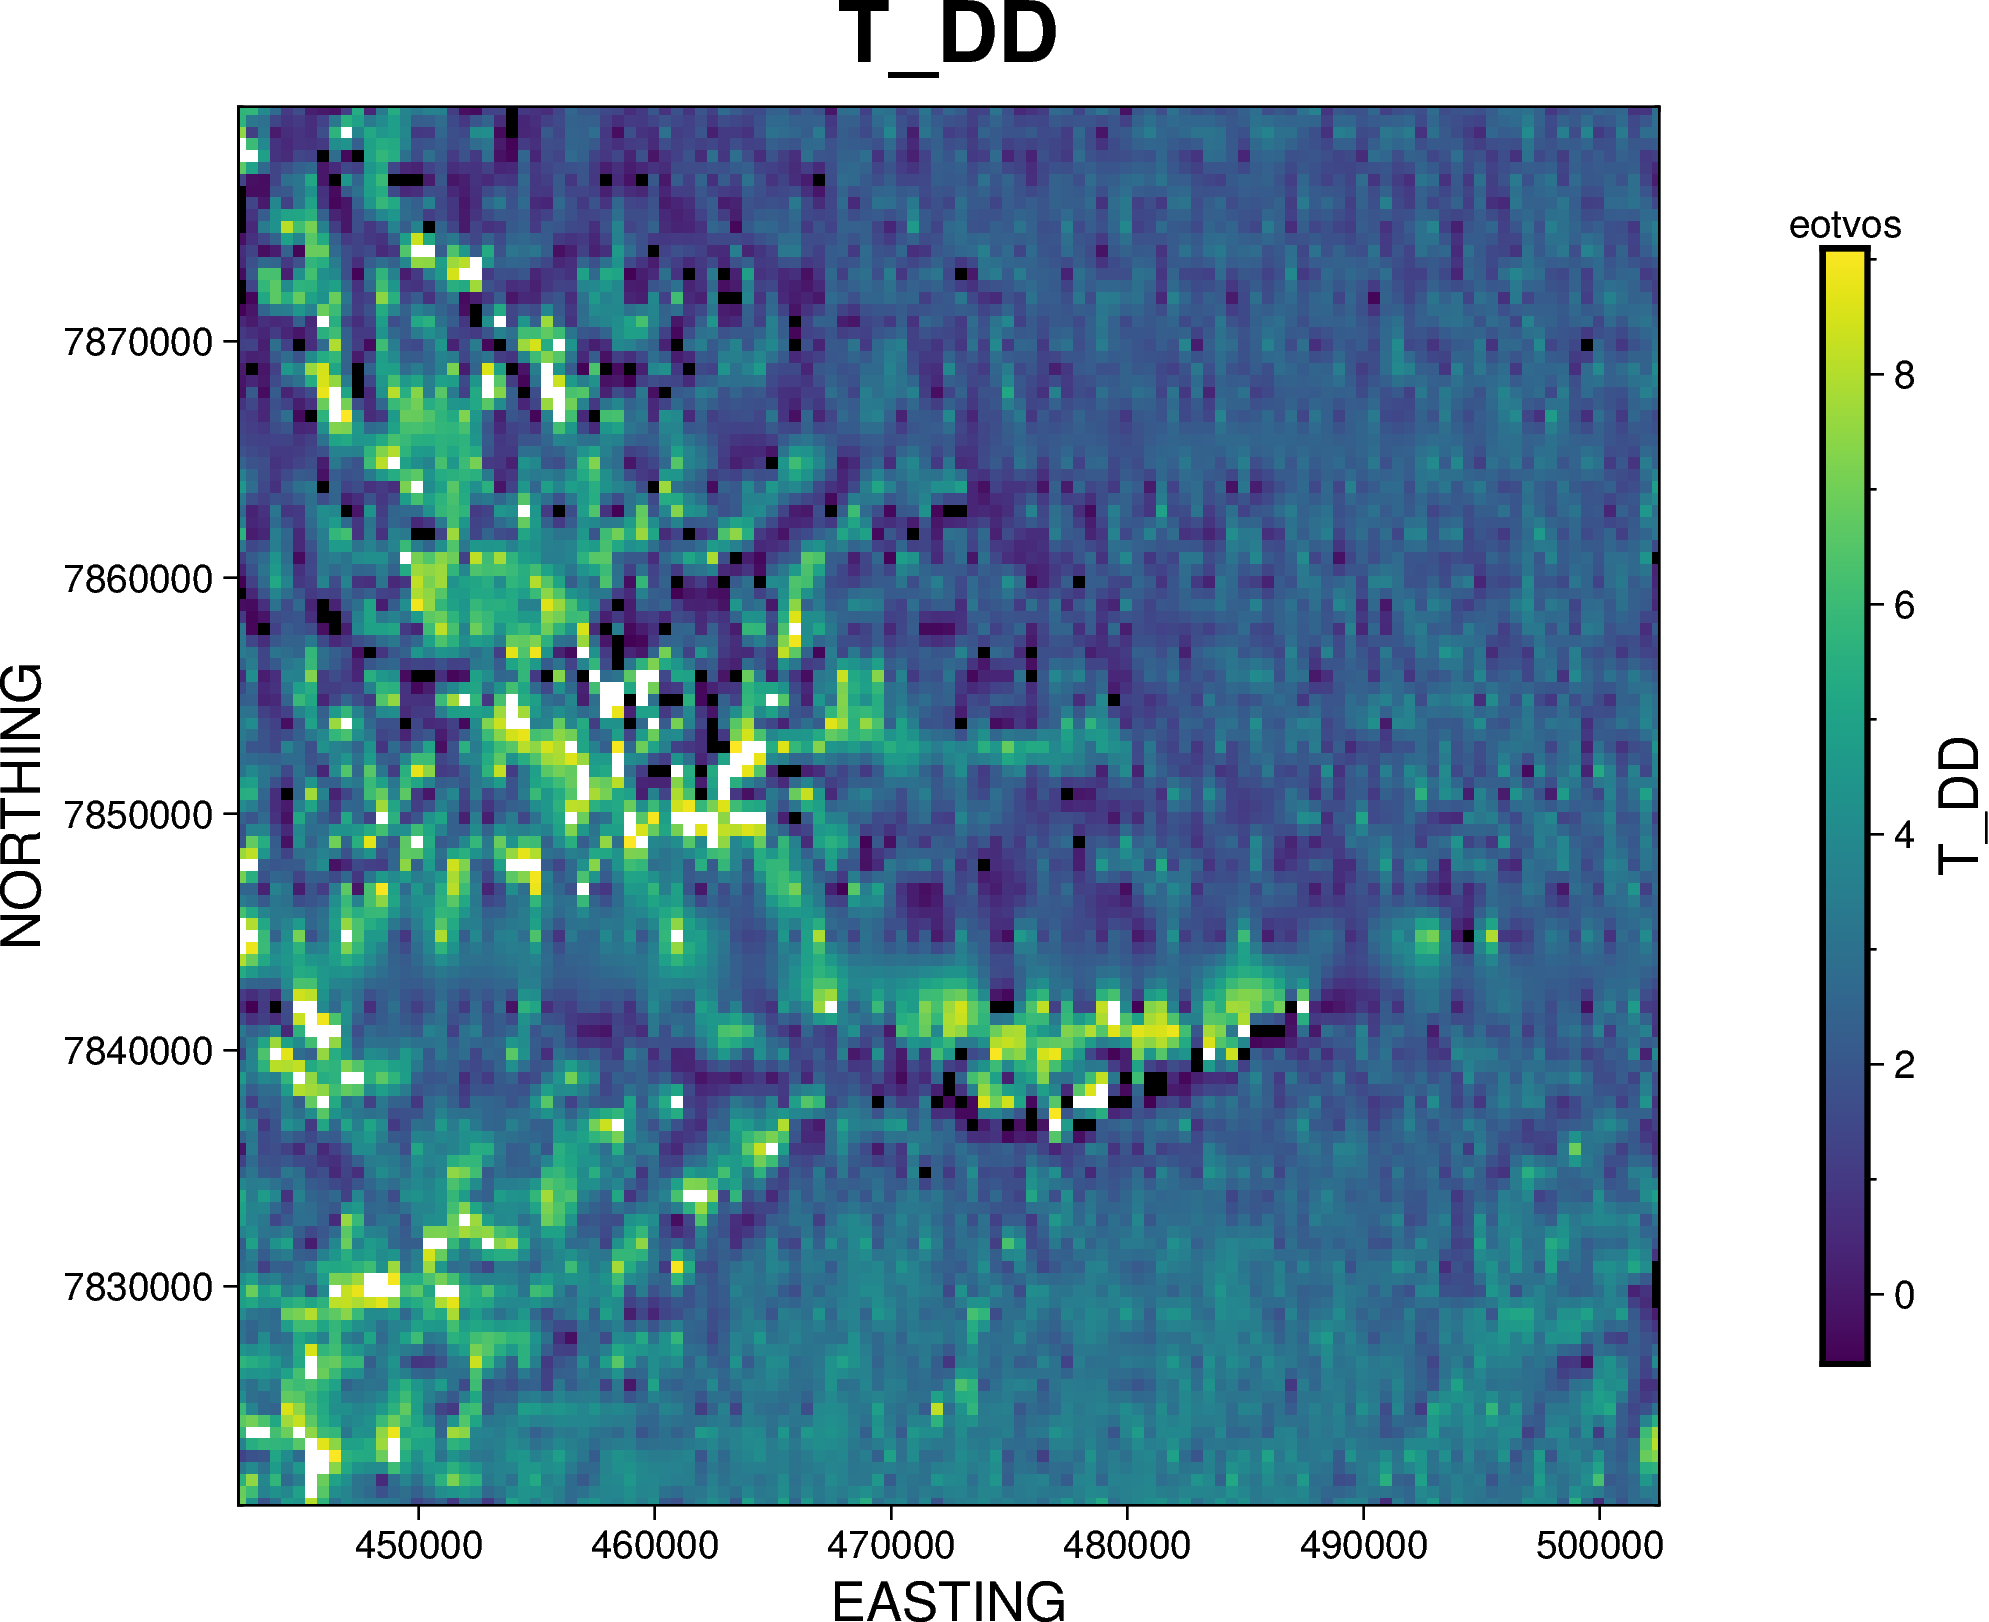

Gridding and imaging Time_1980
Total number of fids in whizz file = 450948.
Processing (x, y, z) = (EASTING, NORTHING, Time_1980). Time_1980 in seconds.
Data points cover region: [ 442442.  502444. 7820809. 7879855.]


surface [WARNING]: Input data lie exactly on a plane.


z range (1st to 99th percentile) (0.125, 0.125)


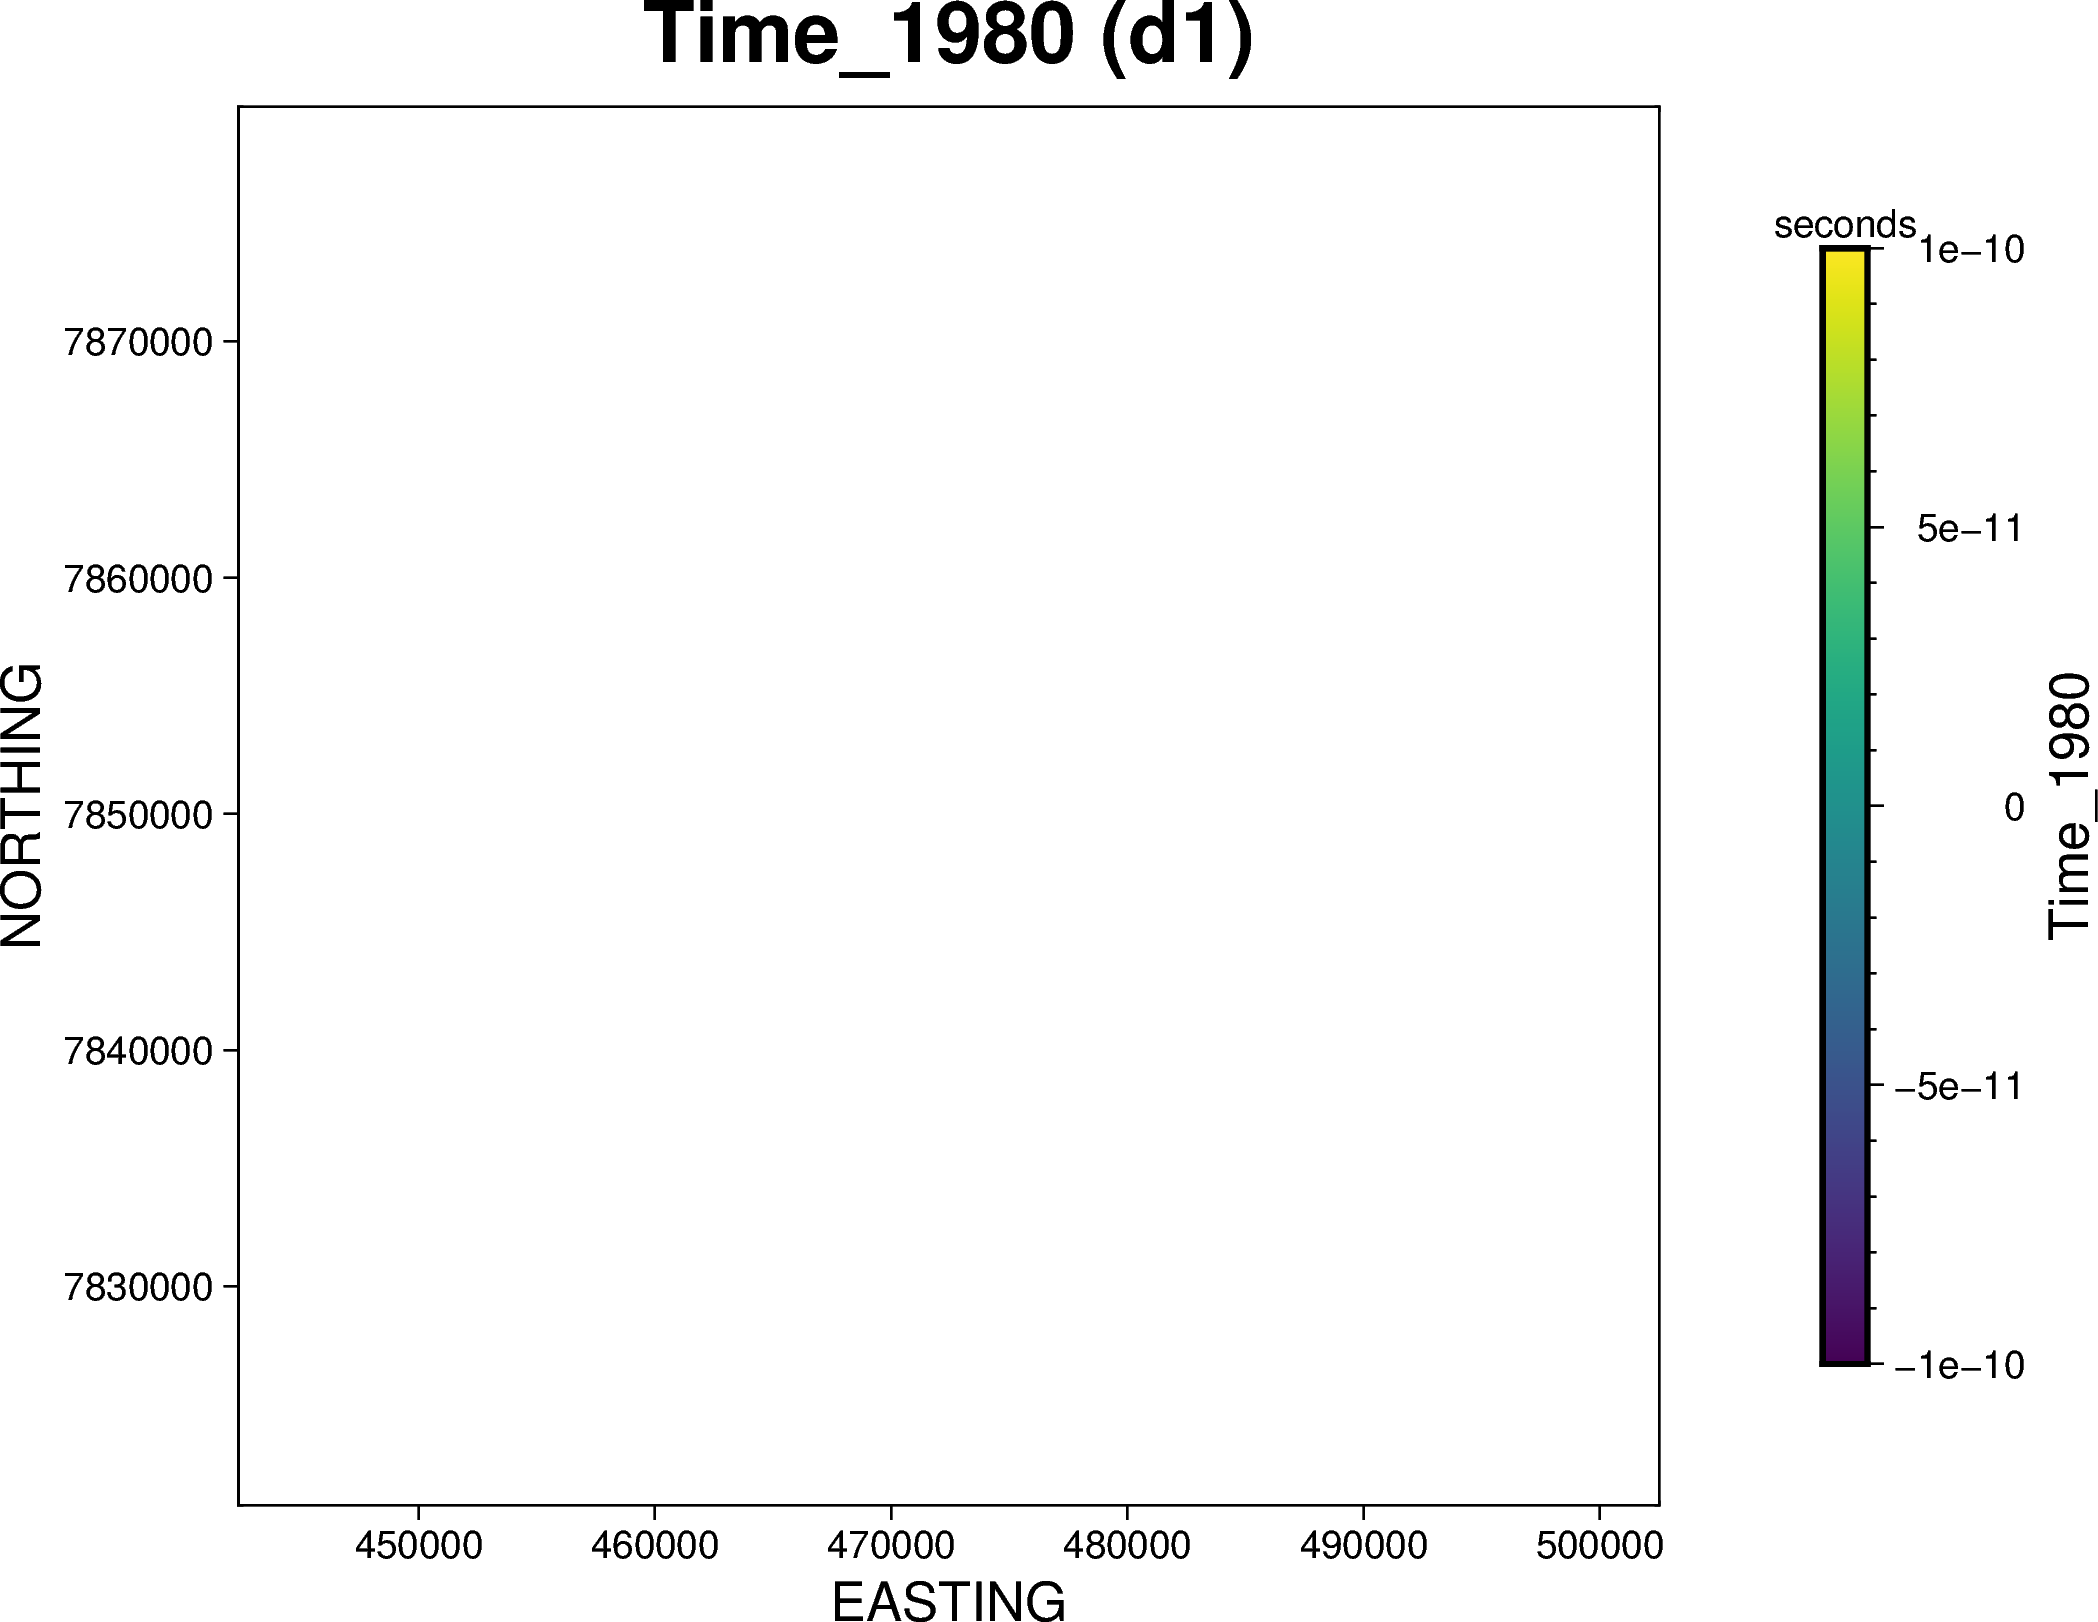

Gridding and imaging gD_Fourier_2p67
Total number of fids in whizz file = 450948.
Processing (x, y, z) = (EASTING, NORTHING, gD_Fourier_2p67). gD_Fourier_2p67 in µm/s/s.
Data points cover region: [ 442442.  502444. 7820809. 7879855.]
z range (1st to 99th percentile) (-19.61, 19.43)


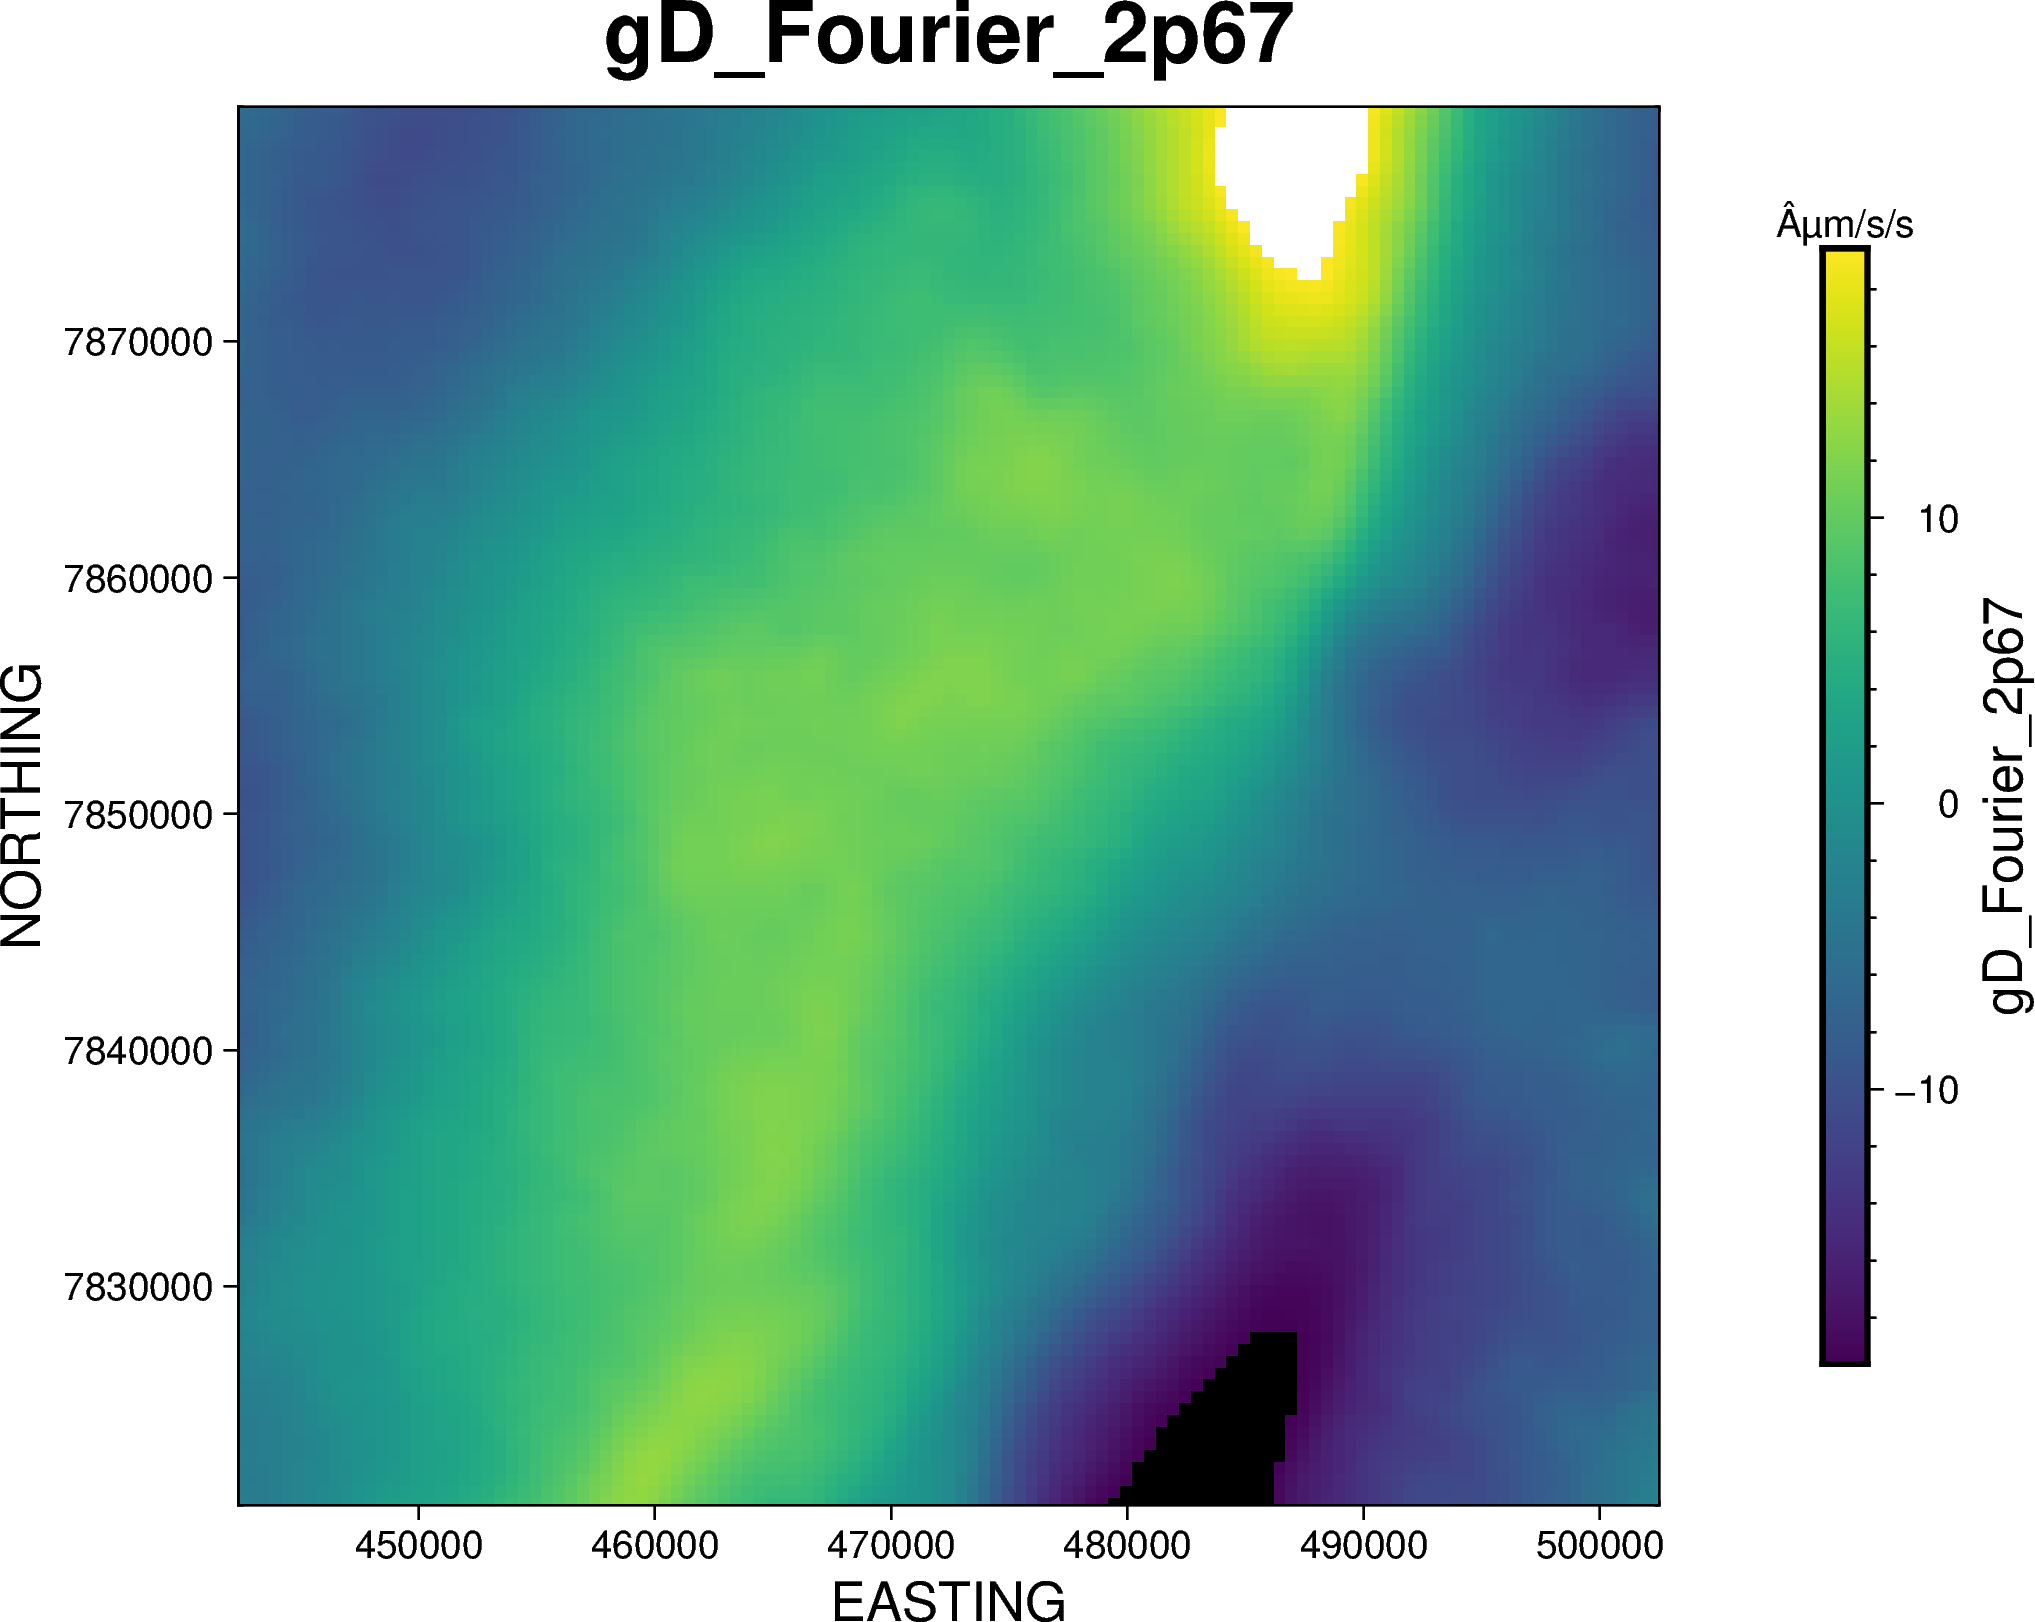

In [6]:
z_chans = ['Bearing', 'CLEARANCE', 'DTM', 'FLIGHT', 'GDD_Fourier_2p67', 'NumSats',
           'T_DD', 'Time_1980', 'gD_Fourier_2p67']
mr_chans = ['Bearing']
d1_chans = ['FLIGHT', 'Time_1980']
erm.grid_n_image(dh, z_chans, mr_chans, d1_chans, 500.0)